# Análisis de Experiencia del Cliente — 06/07/2026

## Pregunta de negocio

**¿Qué aspectos —precisión de los detalles, limpieza, check-in o comunicación— presentan las mayores diferencias entre los alojamientos mejor y peor valorados en la evaluación general?**

Este notebook utiliza el dataset limpio del Sprint 2 y desarrolla el análisis específico del perfil **Analista de Experiencia del Cliente**.

El análisis se organiza en cinco bloques:

1. **Validación de las variables y cobertura de las valoraciones.**
2. **Segmentación de los alojamientos mediante los cuartiles Q1 y Q3.**
3. **Comparación descriptiva y estadística de los cuatro aspectos.**
4. **Comprobación de la consistencia de los resultados entre ciudades.**
5. **Análisis de sensibilidad, sesgos potenciales y recomendación de negocio.**

Los alojamientos sin valoraciones permanecen en el dataset limpio, pero no se imputan ni se incluyen en los cálculos de satisfacción.

### Métrica principal

\[
\text{Diferencia} =
\text{Media}_{\text{mejor valorados}}
-
\text{Media}_{\text{peor valorados}}
\]

Cuanto mayor sea la diferencia, mayor será la capacidad descriptiva del aspecto para distinguir entre los alojamientos con una evaluación general alta y baja.

## 1. Librerías y configuración visual

La paleta mantiene el criterio gráfico utilizado por el equipo en el Sprint anterior:

- **azul marino:** análisis principal;
- **turquesa:** información positiva o validada;
- **amarillo:** referencias, umbrales y elementos destacados;
- **gris:** información neutra, ausente o contextual.

Los tamaños de títulos, etiquetas y valores están ampliados para facilitar la lectura durante la presentación mediante videoproyector.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", 50)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.3f}",
)

NAVY = "#1D5273"
TEAL = "#3FA0A9"
DARK = "#2D3439"
YELLOW = "#FFC43D"
GREY = "#9B9B9B"
LIGHT_GREY = "#E7E7E7"
WHITE = "#FFFFFF"
GRID = "#E2E2E2"
LIGHT_BLUE = "#B9D5E6"
MID_BLUE = "#6FA8C7"
LIGHT_TEAL = "#CFE8E5"
LIGHT_YELLOW = "#FFF0B8"
ROW_LIGHT = "#F7F9FA"
ROW_BLUE = "#DCE9F0"

GROUP_COLORS = {
    "Peor valorados": YELLOW,
    "Intermedios": LIGHT_GREY,
    "Mejor valorados": NAVY,
}

BLUE_CMAP = LinearSegmentedColormap.from_list(
    "stayspain_blues",
    [LIGHT_BLUE, MID_BLUE, NAVY],
)

TITLE_SIZE = 21
AXIS_LABEL_SIZE = 17
TICK_SIZE = 15
LEGEND_SIZE = 14
DATA_LABEL_SIZE = 15
TABLE_FONT_SIZE = 13.5
TABLE_HEADER_SIZE = 14.5

plt.rcParams.update(
    {
        "figure.figsize": (12.5, 7),"figure.dpi": 120,"figure.facecolor": WHITE,"axes.facecolor": WHITE,"axes.titlesize": TITLE_SIZE,
        "axes.titleweight": "bold","axes.titlecolor": DARK,"axes.labelsize": AXIS_LABEL_SIZE,"axes.labelcolor": DARK,
        "axes.edgecolor": GREY,"axes.spines.top": False,"axes.spines.right": False,"xtick.labelsize": TICK_SIZE,"ytick.labelsize": TICK_SIZE,
        "xtick.color": DARK,"ytick.color": DARK,"legend.fontsize": LEGEND_SIZE,"legend.title_fontsize": LEGEND_SIZE,"grid.color": GRID,
        "grid.alpha": 0.75,"font.family": "DejaVu Sans",
    }
)

### 1.1 Funciones auxiliares

In [2]:
def add_vertical_labels(
    ax,
    suffix="",
    decimals=0,
    padding=4,
    fontsize=DATA_LABEL_SIZE,
):
    """Añade etiquetas encima de barras verticales."""

    for patch in ax.patches:
        height = patch.get_height()

        ax.annotate(
            f"{height:.{decimals}f}{suffix}",
            (
                patch.get_x()
                + patch.get_width() / 2,
                height,
            ),
            xytext=(0, padding),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color=DARK,
            fontweight="bold",
        )


def graphic_table(
    dataframe,
    title,
    formats=None,
    highlight_max=None,
    highlight_min=None,
    width=None,
    font_size=None,
):
    """
    Muestra una tabla gráfica con el estilo visual del equipo.
    """

    data = (
        dataframe
        .copy()
        .reset_index(drop=True)
    )

    numeric_data = (
        dataframe
        .copy()
        .reset_index(drop=True)
    )

    formats = formats or {}
    highlight_max = highlight_max or []
    highlight_min = highlight_min or []

    for column, format_text in formats.items():
        if column in data.columns:
            data[column] = data[column].map(
                lambda value: (
                    format_text.format(value)
                    if pd.notna(value)
                    else "—"
                )
            )

    rows, columns = data.shape

    if columns <= 4:
        automatic_font_size = 16

    elif columns <= 7:
        automatic_font_size = 14.5

    else:
        automatic_font_size = 13.5

    if font_size is None:
        body_font_size = automatic_font_size

    else:
        body_font_size = max(
            float(font_size),
            automatic_font_size,
        )

    header_font_size = body_font_size + 1

    if width is None:
        width = max(
            9.5,
            columns * 1.85,
        )

    height = max(
        3.0,
        rows * 0.55 + 1.4,
    )

    fig, ax = plt.subplots(
        figsize=(width, height),
        dpi=120,
    )

    ax.axis("off")

    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[
            0,
            0.03,
            1,
            0.84,
        ],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(body_font_size)

    total_rows = rows + 1
    row_height = 0.84 / total_rows

    for (row, column), cell in table.get_celld().items():

        cell.set_edgecolor(WHITE)
        cell.set_linewidth(1.2)
        cell.set_height(row_height)
        cell.PAD = 0.06

        cell.get_text().set_wrap(True)

        if row == 0:
            cell.set_facecolor(NAVY)

            cell.set_text_props(
                color=WHITE,
                weight="bold",
                fontsize=header_font_size,
                ha="center",
                va="center",
            )

        else:
            cell.set_facecolor(
                ROW_LIGHT
                if row % 2 == 1
                else ROW_BLUE
            )

            cell.set_text_props(
                color=DARK,
                fontsize=body_font_size,
                ha="center",
                va="center",
            )

    for column_name in highlight_max:

        if column_name not in numeric_data.columns:
            continue

        valid_series = pd.to_numeric(
            numeric_data[column_name],
            errors="coerce",
        )

        if valid_series.notna().any():

            row_position = (
                int(valid_series.idxmax())
                + 1
            )

            column_position = (
                data.columns.get_loc(
                    column_name
                )
            )

            selected_cell = table[
                (
                    row_position,
                    column_position,
                )
            ]

            selected_cell.set_facecolor(
                LIGHT_TEAL
            )

            selected_cell.set_text_props(
                color=DARK,
                weight="bold",
                fontsize=body_font_size,
            )

    for column_name in highlight_min:

        if column_name not in numeric_data.columns:
            continue

        valid_series = pd.to_numeric(
            numeric_data[column_name],
            errors="coerce",
        )

        if valid_series.notna().any():

            row_position = (
                int(valid_series.idxmin())
                + 1
            )

            column_position = (
                data.columns.get_loc(
                    column_name
                )
            )

            selected_cell = table[
                (
                    row_position,
                    column_position,
                )
            ]

            selected_cell.set_facecolor(
                LIGHT_YELLOW
            )

            selected_cell.set_text_props(
                color=DARK,
                weight="bold",
                fontsize=body_font_size,
            )

    ax.set_title(
        title,
        fontsize=21,
        fontweight="bold",
        color=DARK,
        pad=4,
        y=0.93,
    )

    plt.subplots_adjust(
        top=0.98,
        bottom=0.02,
        left=0.02,
        right=0.98,
    )

    plt.show()


def holm_adjust(p_values):
    """Ajusta valores p mediante el método de Holm."""

    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)

    running_max = 0.0
    total = len(p_values)

    for position, original_index in enumerate(
        order
    ):
        multiplier = total - position

        candidate = (
            multiplier
            * p_values[original_index]
        )

        running_max = max(
            running_max,
            candidate,
        )

        adjusted[original_index] = min(
            running_max,
            1.0,
        )

    return adjusted


def effect_label(delta):
    """Clasifica la magnitud absoluta del delta de Cliff."""

    absolute_delta = abs(delta)

    if absolute_delta < 0.147:
        return "Despreciable"

    if absolute_delta < 0.330:
        return "Pequeño"

    if absolute_delta < 0.474:
        return "Moderado"

    return "Grande"


def p_value_label(p_value):
    """Formatea el valor p para la presentación."""

    if p_value < 0.001:
        return "< 0,001"

    return (
        f"{p_value:.3f}"
        .replace(".", ",")
    )


def mann_whitney_effect(
    best_values,
    worst_values,
):
    """Calcula Mann–Whitney U, valor p y delta de Cliff."""

    u_statistic, p_value = mannwhitneyu(
        best_values,
        worst_values,
        alternative="two-sided",
        method="asymptotic",
    )

    cliff_delta = (
        2
        * u_statistic
        / (
            len(best_values)
            * len(worst_values)
        )
        - 1
    )

    return (
        u_statistic,
        p_value,
        cliff_delta,
    )


## 2. Carga y validación del dataset

El notebook localiza el dataset tanto desde la raíz del repositorio como desde la carpeta `Scripts`. De este modo, puede ejecutarse en diferentes entornos sin cambiar manualmente la ruta.

In [3]:
def find_dataset():
    """Localiza el dataset desde la raíz o desde Scripts."""

    current = Path.cwd()

    candidates = [
        current / "Data" / "clean_dataset_06_07_2026.csv",
        current.parent / "Data" / "clean_dataset_06_07_2026.csv",
        current / "clean_dataset_06_07_2026.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "No se encontró clean_dataset_06_07_2026.csv."
    )


data_path = find_dataset()
df = pd.read_csv(data_path)

df["city"] = (
    df["city"]
    .astype("string")
    .str.strip()
    .str.title()
)

print(
    f"Dataset cargado: {df.shape[0]:,} filas "
    f"y {df.shape[1]} columnas"
)

Dataset cargado: 7,693 filas y 35 columnas


In [4]:
ASPECT_COLUMNS = {
    "Precisión": "review_scores_accuracy",
    "Limpieza": "review_scores_cleanliness",
    "Check-in": "review_scores_checkin",
    "Comunicación": "review_scores_communication",
}

REQUIRED_COLUMNS = [
    "apartment_id",
    "city",
    "review_scores_rating",
    *ASPECT_COLUMNS.values(),
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"Faltan columnas necesarias: {missing_columns}"
    )

if df["apartment_id"].duplicated().any():
    raise ValueError(
        "El dataset contiene apartment_id duplicados."
    )

rating_max = df["review_scores_rating"].max()

if rating_max > 100:
    df["rating_general_100"] = (
        df["review_scores_rating"] / 10
    )
else:
    df["rating_general_100"] = (
        df["review_scores_rating"]
    )

for aspect, column in ASPECT_COLUMNS.items():
    maximum = df[column].max()

    if maximum <= 10:
        df[f"{column}_100"] = df[column] * 10
    else:
        df[f"{column}_100"] = df[column]

ASPECT_COLUMNS_100 = {
    aspect: f"{column}_100"
    for aspect, column in ASPECT_COLUMNS.items()
}

validation_columns = [
    "rating_general_100",
    *ASPECT_COLUMNS_100.values(),
]

for column in validation_columns:
    valid_values = (
        df[column].isna()
        | df[column].between(0, 100)
    )

    if not valid_values.all():
        raise ValueError(
            f"{column} contiene valores fuera de 0–100."
        )

print(
    "Escalas validadas y expresadas "
    "en una escala común de 0 a 100."
)

Escalas validadas y expresadas en una escala común de 0 a 100.


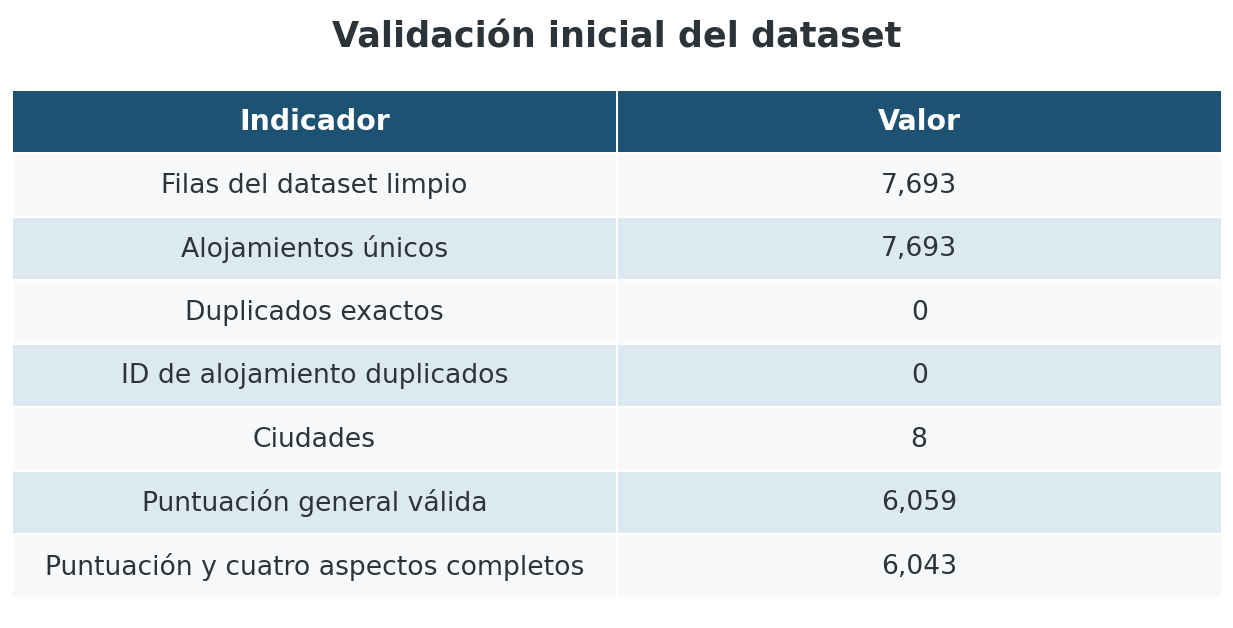

In [5]:
complete_columns = [
    "rating_general_100",
    *ASPECT_COLUMNS_100.values(),
]

df_valid_rating = df.dropna(
    subset=["rating_general_100"]
).copy()

df_complete = df.dropna(
    subset=complete_columns
).copy()

quality_summary = pd.DataFrame(
    {
        "Indicador": [
            "Filas del dataset limpio",
            "Alojamientos únicos",
            "Duplicados exactos",
            "ID de alojamiento duplicados",
            "Ciudades",
            "Puntuación general válida",
            "Puntuación y cuatro aspectos completos",
        ],
        "Valor": [
            len(df),
            df["apartment_id"].nunique(),
            df.duplicated().sum(),
            df["apartment_id"].duplicated().sum(),
            df["city"].nunique(),
            len(df_valid_rating),
            len(df_complete),
        ],
    }
)

graphic_table(
    quality_summary,
    "Validación inicial del dataset",
    formats={"Valor": "{:,.0f}"},
    width=10.5,
)

### Interpretación

El dataset limpio contiene **7.693 alojamientos únicos**
y no presenta duplicados exactos ni identificadores
repetidos. Hay **6.059 alojamientos con puntuación general
válida** y **6.043 con las cinco puntuaciones completas**,
que constituyen la muestra final del análisis.

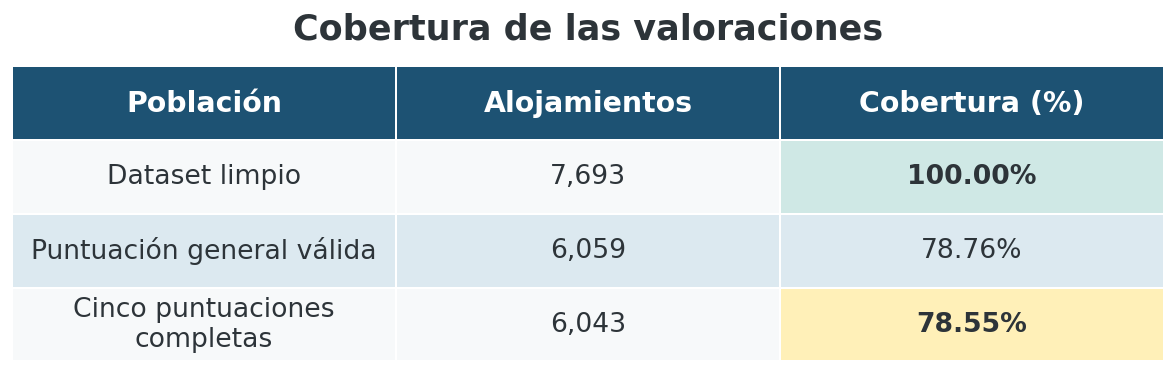

In [6]:
coverage_summary = pd.DataFrame(
    {
        "Población": [
            "Dataset limpio",
            "Puntuación general válida",
            "Cinco puntuaciones completas",
        ],
        "Alojamientos": [
            len(df),
            len(df_valid_rating),
            len(df_complete),
        ],
        "Cobertura (%)": [
            100,
            len(df_valid_rating) / len(df) * 100,
            len(df_complete) / len(df) * 100,
        ],
    }
)

graphic_table(
    coverage_summary,
    "Cobertura de las valoraciones",
    formats={
        "Alojamientos": "{:,.0f}",
        "Cobertura (%)": "{:.2f}%",
    },
    highlight_max=["Cobertura (%)"],
    highlight_min=["Cobertura (%)"],
    width=10,
)

### Interpretación

El **78,55 %** de los alojamientos dispone de la puntuación
general y de los cuatro aspectos completos. La mayor parte
de la pérdida de casos se debe a alojamientos sin valoración
general; entre los casos con rating válido, solo 16 presentan
algún aspecto incompleto.

## 3. Calidad y cobertura por ciudad

La cobertura se utiliza como indicador de calidad del dato. No representa satisfacción, pero permite detectar ciudades cuyos resultados deben interpretarse con mayor cautela.

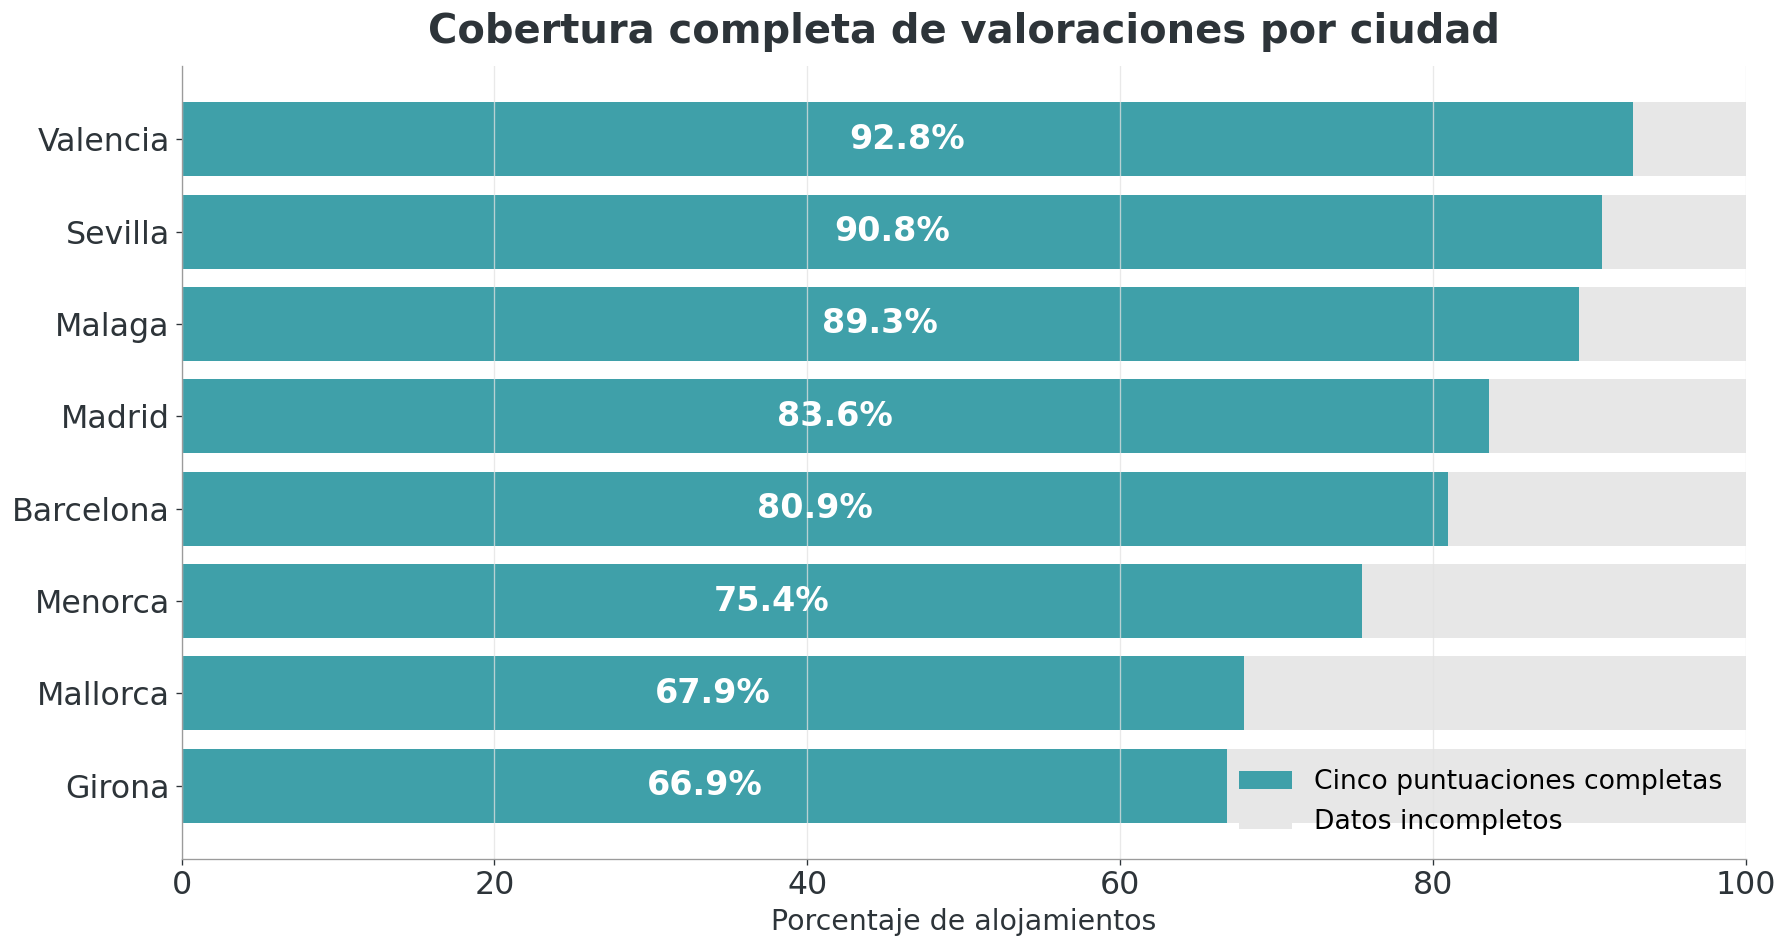

In [7]:
coverage_by_city = (
    df.groupby("city", as_index=False)
    .agg(
        Alojamientos=(
            "apartment_id",
            "nunique",
        ),
        Rating_valido=(
            "rating_general_100",
            "count",
        ),
    )
)

complete_by_city = (
    df_complete.groupby("city")
    .size()
    .rename("Casos_completos")
)

coverage_by_city = (
    coverage_by_city
    .set_index("city")
    .join(complete_by_city)
    .fillna(0)
    .reset_index()
    .rename(columns={"city": "Ciudad"})
)

coverage_by_city[
    "Cobertura completa (%)"
] = (
    coverage_by_city["Casos_completos"]
    / coverage_by_city["Alojamientos"]
    * 100
)

coverage_by_city[
    "Sin datos completos (%)"
] = (
    100
    - coverage_by_city[
        "Cobertura completa (%)"
    ]
)

coverage_plot = coverage_by_city.sort_values(
    "Cobertura completa (%)"
)

fig, ax = plt.subplots(figsize=(15, 8))

ax.barh(
    coverage_plot["Ciudad"],
    coverage_plot["Cobertura completa (%)"],
    color=TEAL,
    label="Cinco puntuaciones completas",
)

ax.barh(
    coverage_plot["Ciudad"],
    coverage_plot["Sin datos completos (%)"],
    left=coverage_plot[
        "Cobertura completa (%)"
    ],
    color=LIGHT_GREY,
    label="Datos incompletos",
)

for position, value in enumerate(
    coverage_plot["Cobertura completa (%)"]
):
    ax.text(
        value / 2,
        position,
        f"{value:.1f}%",
        ha="center",
        va="center",
        color=WHITE,
        fontsize=20,
        fontweight="bold",
    )

ax.set(
    xlabel="Porcentaje de alojamientos",
    ylabel="",
    xlim=(0, 100),
)

ax.set_title(
    "Cobertura completa de valoraciones por ciudad",
    fontsize=24,
    fontweight="bold",
    color=DARK,
    pad=14,
)

ax.tick_params(
    axis="x",
    labelsize=19,
)

ax.tick_params(
    axis="y",
    labelsize=19,
)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=16,
)

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

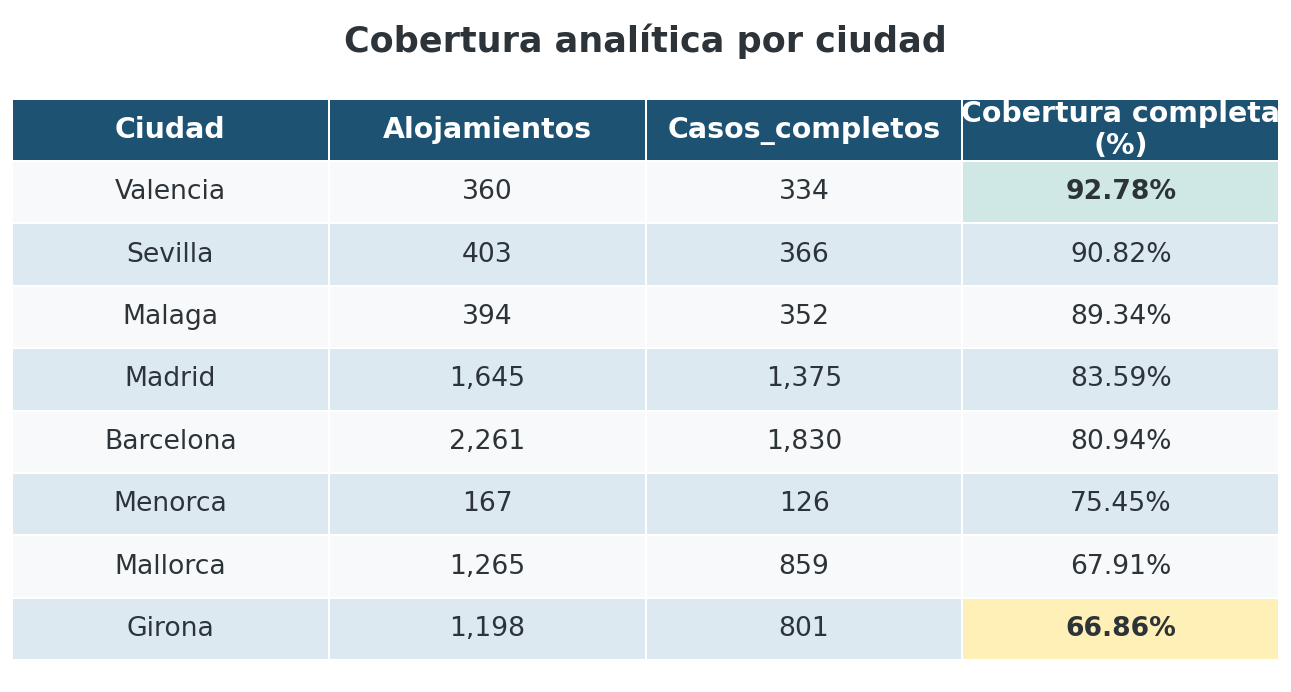

In [8]:
coverage_table = coverage_by_city[
    [
        "Ciudad",
        "Alojamientos",
        "Casos_completos",
        "Cobertura completa (%)",
    ]
].sort_values(
    "Cobertura completa (%)",
    ascending=False,
).reset_index(drop=True)

graphic_table(
    coverage_table,
    "Cobertura analítica por ciudad",
    formats={
        "Alojamientos": "{:,.0f}",
        "Casos_completos": "{:,.0f}",
        "Cobertura completa (%)": "{:.2f}%",
    },
    highlight_max=["Cobertura completa (%)"],
    highlight_min=["Cobertura completa (%)"],
    width=11,
)

### Interpretación

La cobertura es más alta en **Valencia (92,78 %)**,
**Sevilla (90,82 %)** y **Málaga (89,34 %)**. Girona
y Mallorca presentan las coberturas más bajas, con
**66,86 %** y **67,91 %**, por lo que sus resultados
territoriales deben interpretarse con mayor cautela.

## 4. Exploración de las puntuaciones

Se revisan la distribución de la puntuación general, el efecto techo de los cuatro aspectos y su asociación exploratoria con la evaluación general.

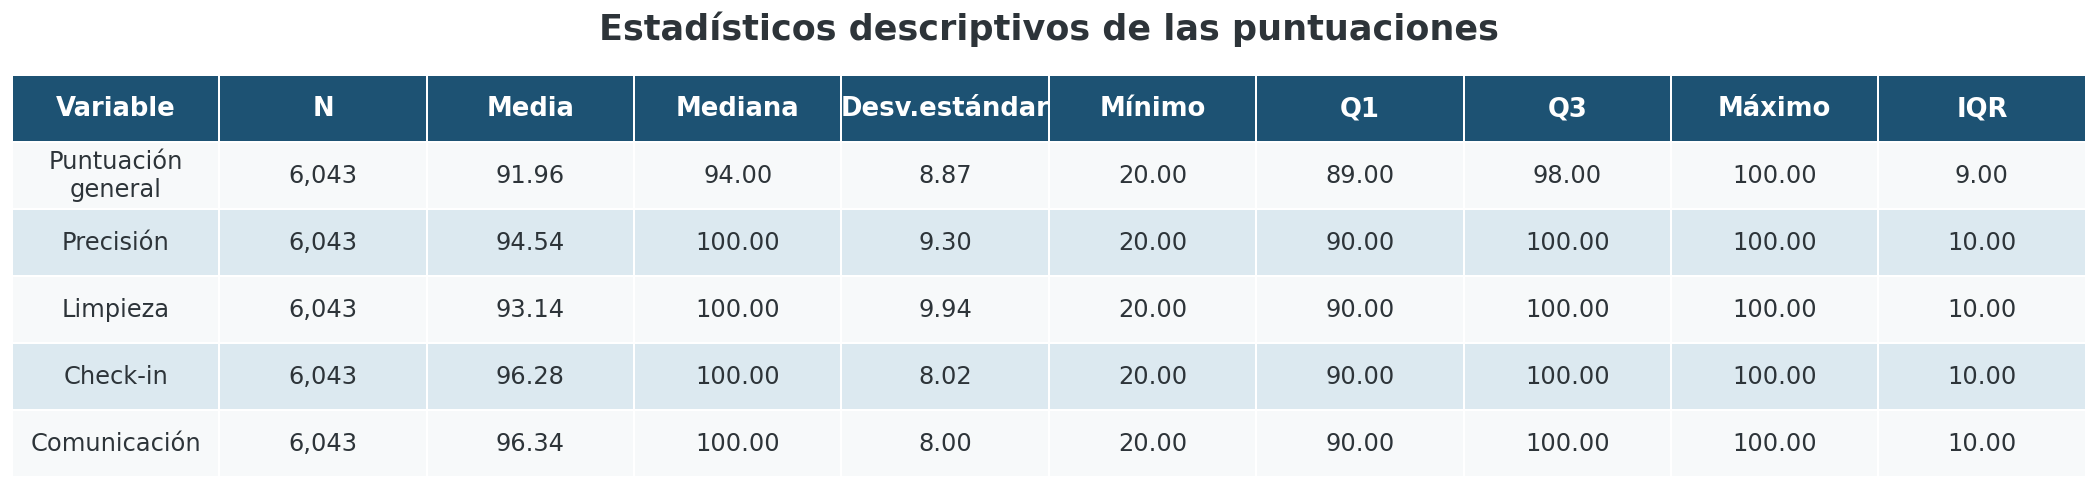

In [9]:
score_columns = {
    "rating_general_100": "Puntuación general",
    **{
        column: aspect
        for aspect, column
        in ASPECT_COLUMNS_100.items()
    },
}

score_summary = (
    df_complete[list(score_columns)]
    .rename(columns=score_columns)
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "Variable"})
)

score_summary["IQR"] = (
    score_summary["75%"]
    - score_summary["25%"]
)

score_table = score_summary[
    [
        "Variable",
        "count",
        "mean",
        "50%",
        "std",
        "min",
        "25%",
        "75%",
        "max",
        "IQR",
    ]
].rename(
    columns={
        "count": "N",
        "mean": "Media",
        "50%": "Mediana",
        "std": "Desv.estándar",
        "min": "Mínimo",
        "25%": "Q1",
        "75%": "Q3",
        "max": "Máximo",
    }
)

graphic_table(
    score_table,
    "Estadísticos descriptivos de las puntuaciones",
    formats={
        "N": "{:,.0f}",
        "Media": "{:.2f}",
        "Mediana": "{:.2f}",
        "Desv.estándar": "{:.2f}",
        "Mínimo": "{:.2f}",
        "Q1": "{:.2f}",
        "Q3": "{:.2f}",
        "Máximo": "{:.2f}",
        "IQR": "{:.2f}",
    },
    width=18,
    font_size=14.5,
)

### Interpretación

La puntuación general presenta una media de **91,96** y una
mediana de **94**. Los cuatro aspectos tienen una mediana
de 100, lo que confirma un efecto techo. Limpieza registra
la media más baja (**93,14**), mientras que comunicación
y check-in presentan las medias más elevadas.

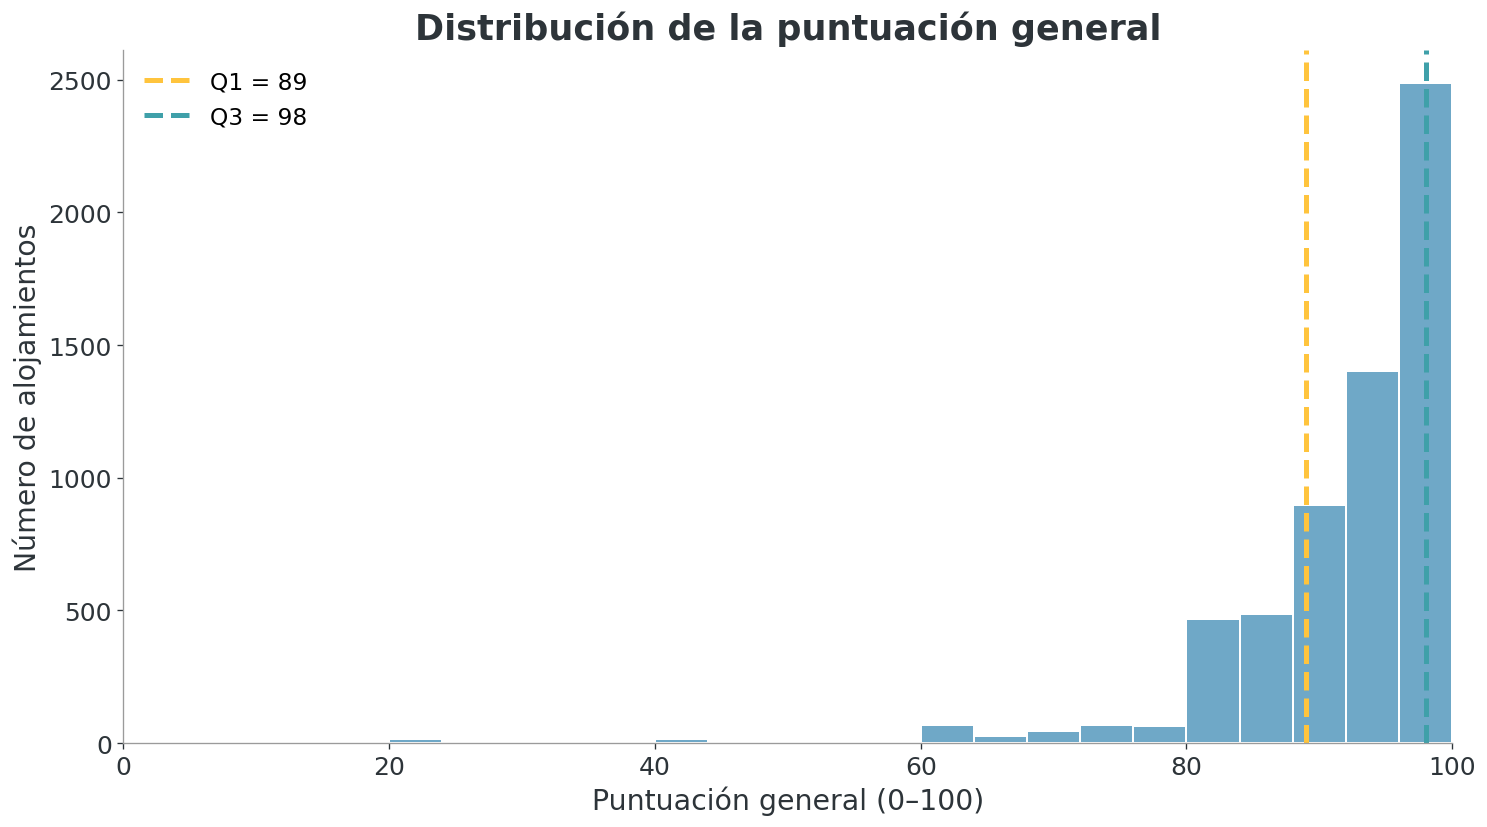

In [10]:
q1_all = df_valid_rating[
    "rating_general_100"
].quantile(0.25)

q3_all = df_valid_rating[
    "rating_general_100"
].quantile(0.75)

fig, ax = plt.subplots(figsize=(12.5, 7))

ax.hist(
    df_valid_rating["rating_general_100"],
    bins=20,
    color=MID_BLUE,
    edgecolor=WHITE,
    linewidth=1.2,
)

ax.axvline(
    q1_all,
    color=YELLOW,
    linestyle="--",
    linewidth=3,
    label=f"Q1 = {q1_all:.0f}",
)

ax.axvline(
    q3_all,
    color=TEAL,
    linestyle="--",
    linewidth=3,
    label=f"Q3 = {q3_all:.0f}",
)

ax.set(
    title="Distribución de la puntuación general",
    xlabel="Puntuación general (0–100)",
    ylabel="Número de alojamientos",
    xlim=(0, 100),
)

ax.legend(
    frameon=False,
    loc="upper left",
)

plt.tight_layout()
plt.show()

### Interpretación

La distribución está concentrada en puntuaciones altas.
El percentil 25 se sitúa en **89** y el percentil 75 en
**98**. La acumulación de observaciones en valores altos
explica la presencia de numerosos empates en los puntos
de corte.

### Correlación exploratoria

Se utiliza el coeficiente de Spearman porque las puntuaciones presentan asimetría, efecto techo y numerosos valores repetidos. Esta correlación es complementaria: la respuesta principal se basa en la diferencia entre los grupos extremos.

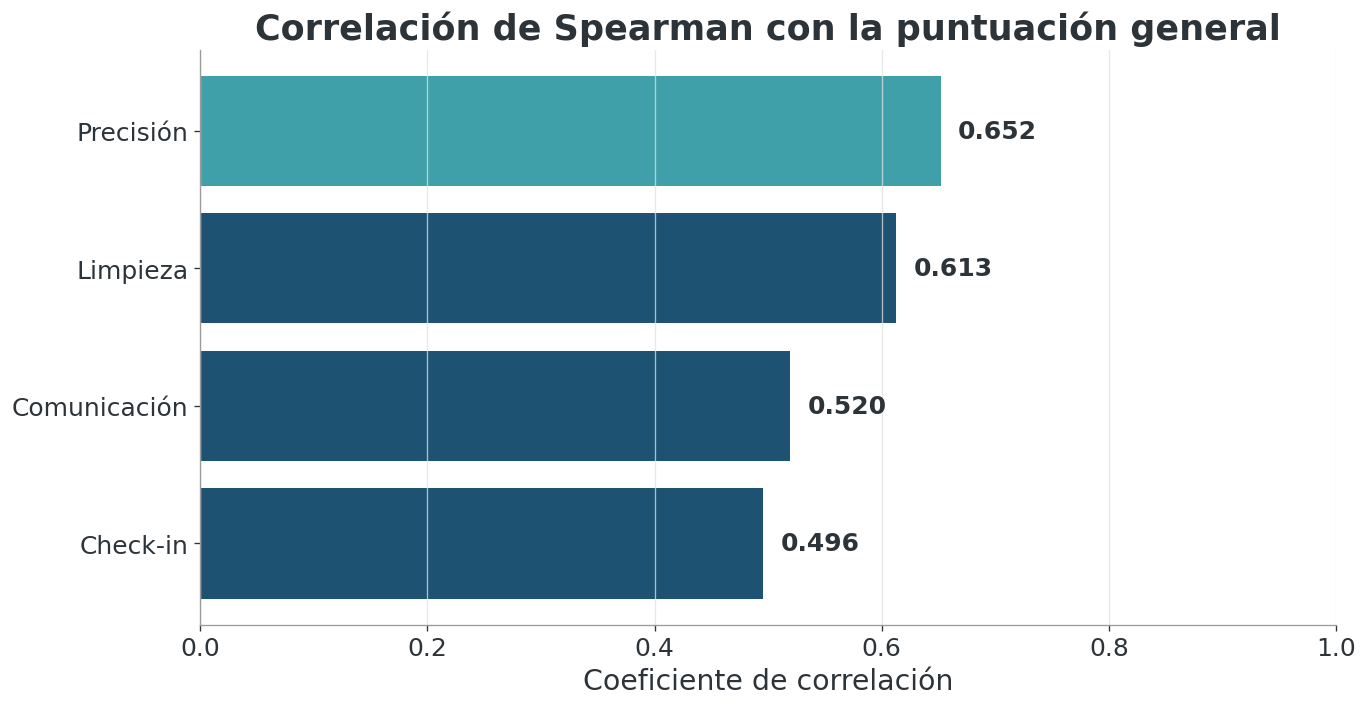

In [11]:
correlation_data = (
    df_complete[list(score_columns)]
    .rename(columns=score_columns)
)

spearman_matrix = correlation_data.corr(
    method="spearman"
)

rating_correlations = (
    spearman_matrix["Puntuación general"]
    .drop("Puntuación general")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11.5, 6))

colors = [
    TEAL
    if value == rating_correlations.max()
    else NAVY
    for value in rating_correlations
]

bars = ax.barh(
    rating_correlations.index,
    rating_correlations.values,
    color=colors,
)

ax.set(
    title="Correlación de Spearman con la puntuación general",
    xlabel="Coeficiente de correlación",
    ylabel="",
    xlim=(0, 1),
)

for bar, value in zip(
    bars,
    rating_correlations.values,
):
    ax.text(
        value + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=DATA_LABEL_SIZE,
        fontweight="bold",
        color=DARK,
    )

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Interpretación

Todos los aspectos muestran una asociación positiva con
la puntuación general. Precisión presenta la correlación
más alta (**ρ = 0,652**), seguida de limpieza
(**ρ = 0,613**). Comunicación y check-in también están
relacionados con el rating general, aunque con menor
intensidad. Estas asociaciones no implican causalidad.

## 5. Segmentación mediante cuartiles

Los puntos de corte se calculan con todos los alojamientos que tienen una puntuación general válida:

- **Peor valorados:** puntuación general ≤ Q1.
- **Mejor valorados:** puntuación general ≥ Q3.
- **Intermedios:** puntuaciones situadas entre Q1 y Q3.

Los alojamientos intermedios se mantienen en el dataset de trabajo, pero no se incluyen en la comparación principal.

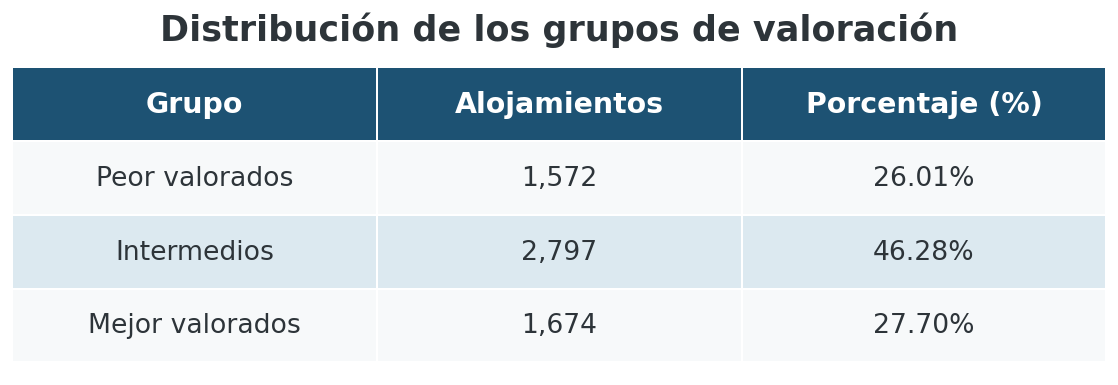

Percentil 25 (Q1): 89.0
Percentil 75 (Q3): 98.0


In [12]:
q1 = q1_all
q3 = q3_all

df_complete["grupo_valoracion"] = np.select(
    [
        df_complete["rating_general_100"] <= q1,
        df_complete["rating_general_100"] >= q3,
    ],
    [
        "Peor valorados",
        "Mejor valorados",
    ],
    default="Intermedios",
)

group_counts = (
    df_complete["grupo_valoracion"]
    .value_counts()
    .reindex(
        [
            "Peor valorados",
            "Intermedios",
            "Mejor valorados",
        ]
    )
    .rename_axis("Grupo")
    .reset_index(name="Alojamientos")
)

group_counts["Porcentaje (%)"] = (
    group_counts["Alojamientos"]
    / len(df_complete)
    * 100
)

graphic_table(
    group_counts,
    "Distribución de los grupos de valoración",
    formats={
        "Alojamientos": "{:,.0f}",
        "Porcentaje (%)": "{:.2f}%",
    },
    width=9.5,
)

print(f"Percentil 25 (Q1): {q1:.1f}")
print(f"Percentil 75 (Q3): {q3:.1f}")

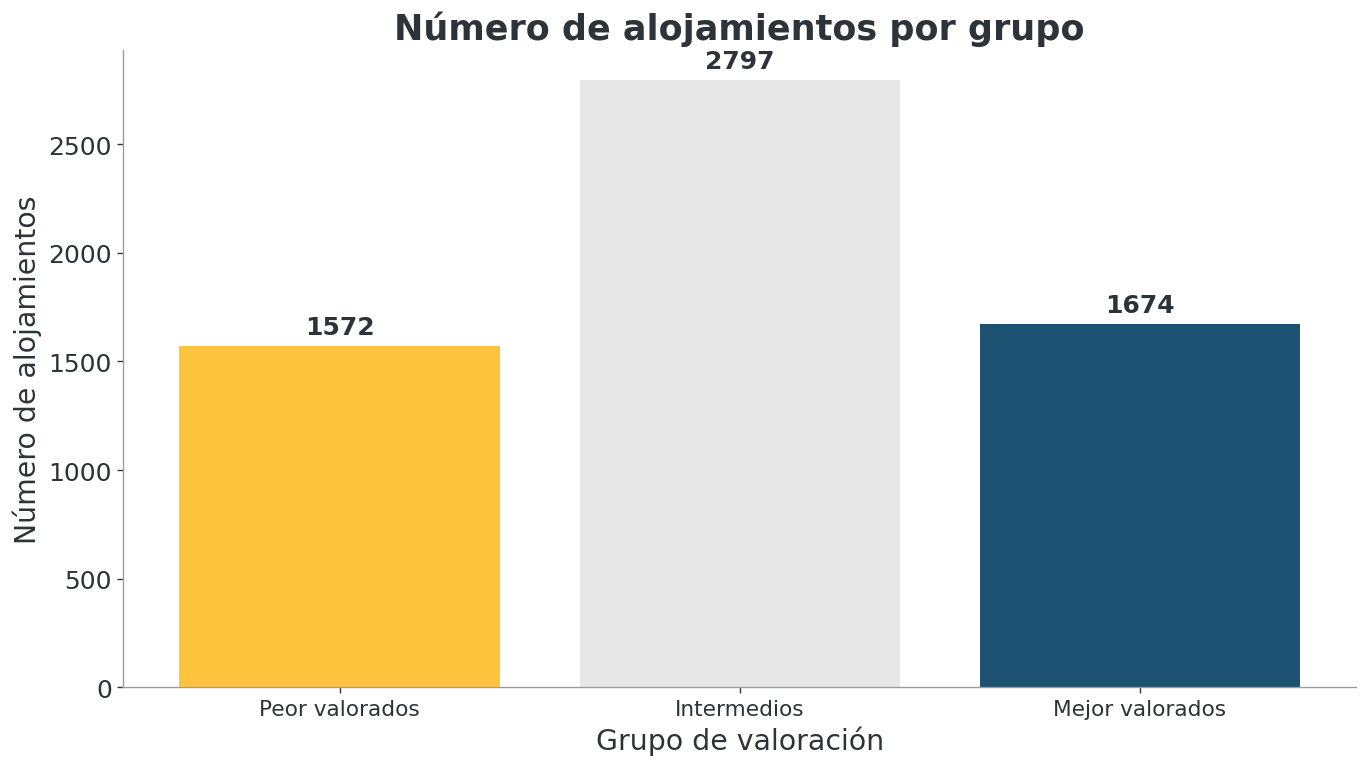

In [13]:
fig, ax = plt.subplots(figsize=(11.5, 6.5))

bars = ax.bar(
    group_counts["Grupo"],
    group_counts["Alojamientos"],
    color=[
        GROUP_COLORS[group]
        for group in group_counts["Grupo"]
    ],
)

ax.set(
    title="Número de alojamientos por grupo",
    xlabel="Grupo de valoración",
    ylabel="Número de alojamientos",
)

add_vertical_labels(
    ax,
    decimals=0,
    fontsize=DATA_LABEL_SIZE,
)

ax.tick_params(
    axis="x",
    labelsize=13,
)

plt.tight_layout()
plt.show()

### Interpretación

La segmentación genera **1.572 alojamientos peor valorados**
y **1.674 mejor valorados**, por lo que los dos grupos
principales tienen tamaños comparables. El grupo intermedio
contiene 2.797 alojamientos. Debido a los empates en Q1 y Q3,
los grupos extremos representan algo más del 50 % del total.

La inclusión de los valores iguales a Q1 y Q3 puede producir grupos ligeramente superiores al 25 % debido a los empates en las puntuaciones.

In [14]:
GROUP_ORDER = [
    "Peor valorados",
    "Mejor valorados",
]

df_extremes = df_complete[
    df_complete["grupo_valoracion"].isin(
        GROUP_ORDER
    )
].copy()

print(
    "Alojamientos incluidos en la comparación: "
    f"{len(df_extremes):,}"
)

Alojamientos incluidos en la comparación: 3,246


## 6. Comparación descriptiva entre los grupos

El siguiente gráfico compara la distribución de los cuatro
aspectos entre los alojamientos mejor y peor valorados.
Permite observar las diferencias centrales, la dispersión
y los valores extremos de cada grupo.

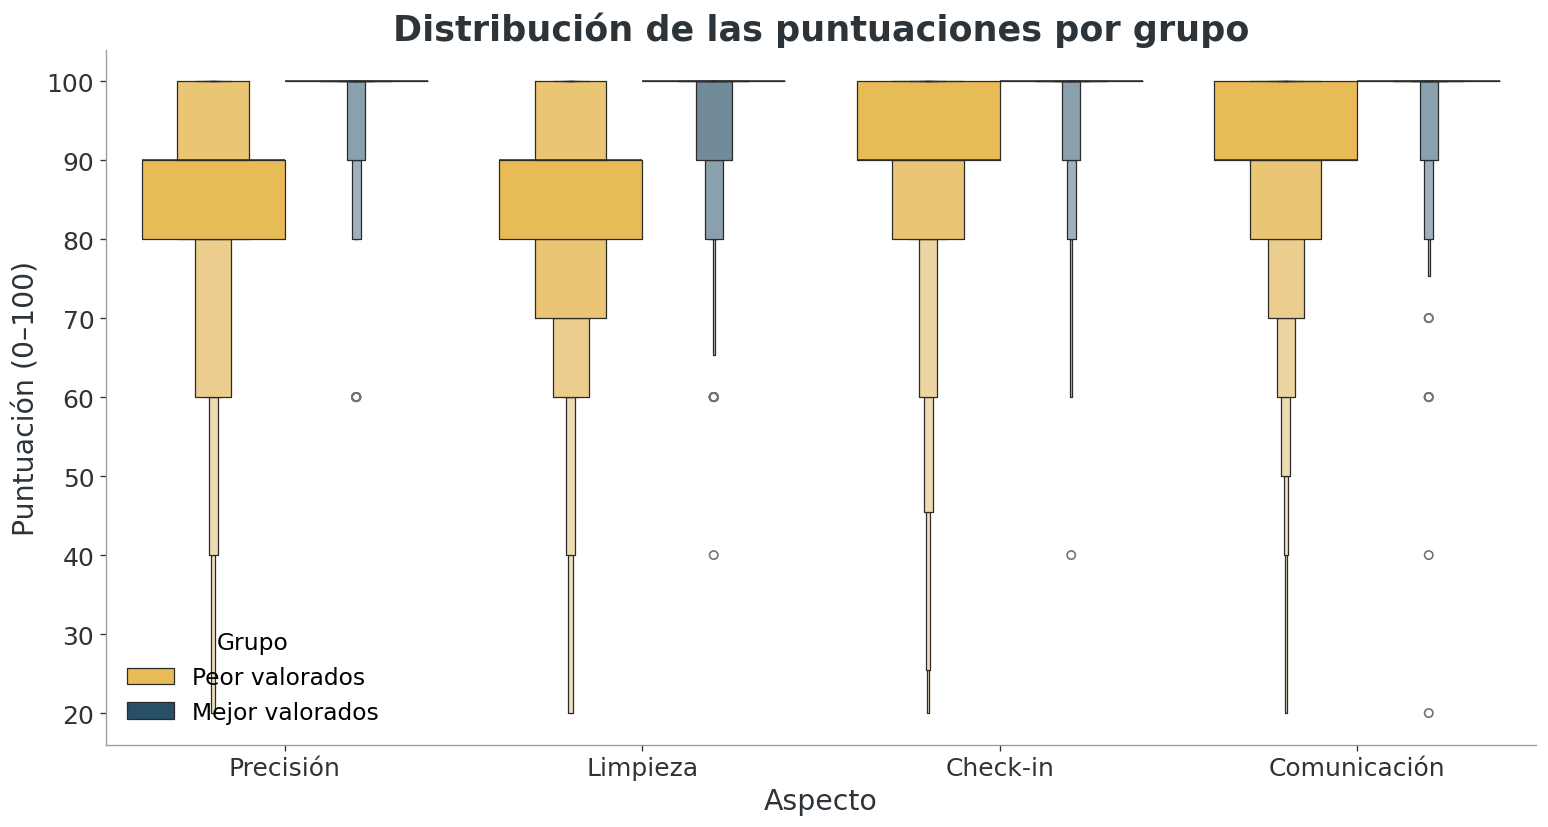

In [15]:
long_data = df_extremes.melt(
    id_vars="grupo_valoracion",
    value_vars=list(
        ASPECT_COLUMNS_100.values()
    ),
    var_name="Variable",
    value_name="Puntuación",
)

aspect_labels = {
    column: aspect
    for aspect, column
    in ASPECT_COLUMNS_100.items()
}

long_data["Aspecto"] = (
    long_data["Variable"]
    .map(aspect_labels)
)

fig, ax = plt.subplots(
    figsize=(13, 7)
)

sns.boxenplot(
    data=long_data,
    x="Aspecto",
    y="Puntuación",
    hue="grupo_valoracion",
    hue_order=[
        "Peor valorados",
        "Mejor valorados",
    ],
    palette={
        "Peor valorados": GROUP_COLORS[
            "Peor valorados"
        ],
        "Mejor valorados": GROUP_COLORS[
            "Mejor valorados"
        ],
    },
    ax=ax,
)

ax.set(
    title="Distribución de las puntuaciones por grupo",
    xlabel="Aspecto",
    ylabel="Puntuación (0–100)",
)

ax.legend(
    title="Grupo",
    frameon=False,
    loc="lower left",
)

plt.tight_layout()
plt.show()

### Interpretación

Los alojamientos mejor valorados se concentran cerca de
las puntuaciones máximas y presentan poca dispersión.
En el grupo peor valorado las puntuaciones son más variables.
La separación visual es especialmente clara en limpieza
y precisión, mientras que comunicación y check-in mantienen
niveles relativamente altos incluso en el grupo peor valorado.

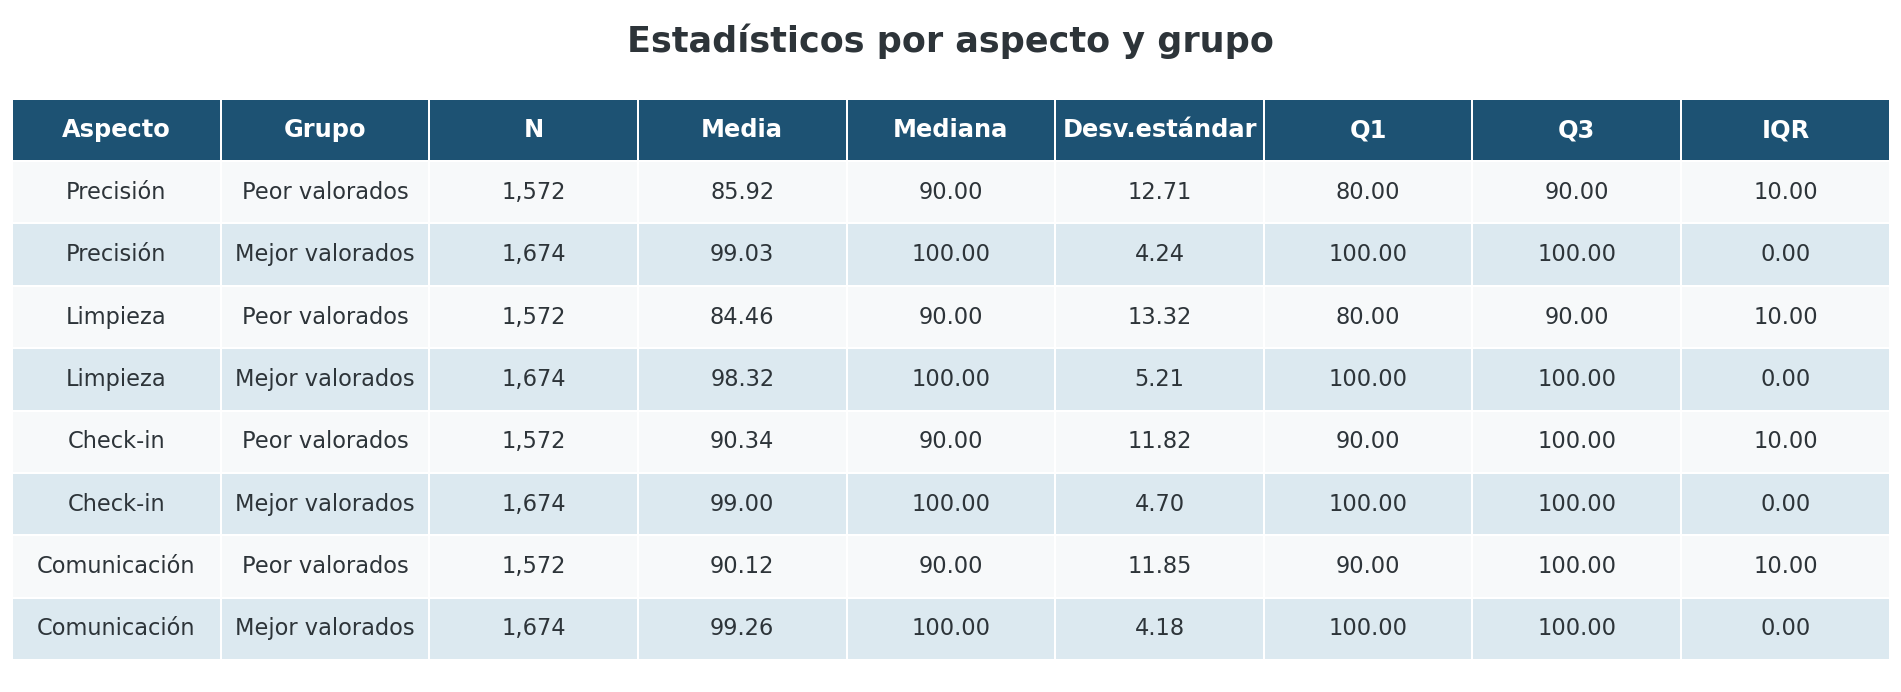

In [16]:
descriptive_rows = []

for aspect, column in ASPECT_COLUMNS_100.items():
    for group in GROUP_ORDER:
        values = df_extremes.loc[
            df_extremes["grupo_valoracion"] == group,
            column,
        ]

        descriptive_rows.append(
            {
                "Aspecto": aspect,
                "Grupo": group,
                "N": len(values),
                "Media": values.mean(),
                "Mediana": values.median(),
                "Desv.estándar": values.std(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "IQR": (
                    values.quantile(0.75)
                    - values.quantile(0.25)
                ),
            }
        )

descriptive_results = pd.DataFrame(
    descriptive_rows
)

graphic_table(
    descriptive_results,
    "Estadísticos por aspecto y grupo",
    formats={
        "N": "{:,.0f}",
        "Media": "{:.2f}",
        "Mediana": "{:.2f}",
        "Desv.estándar": "{:.2f}",
        "Q1": "{:.2f}",
        "Q3": "{:.2f}",
        "IQR": "{:.2f}",
    },
    width=16.3,
    font_size=12.5,
)

### Interpretación

Los alojamientos peor valorados presentan medias más bajas
y una dispersión mayor en los cuatro aspectos. En el grupo
mejor valorado, el rango intercuartílico es 0 en todos los
aspectos debido a la alta concentración de puntuaciones en
100. Esta asimetría respalda el uso de una prueba no
paramétrica.

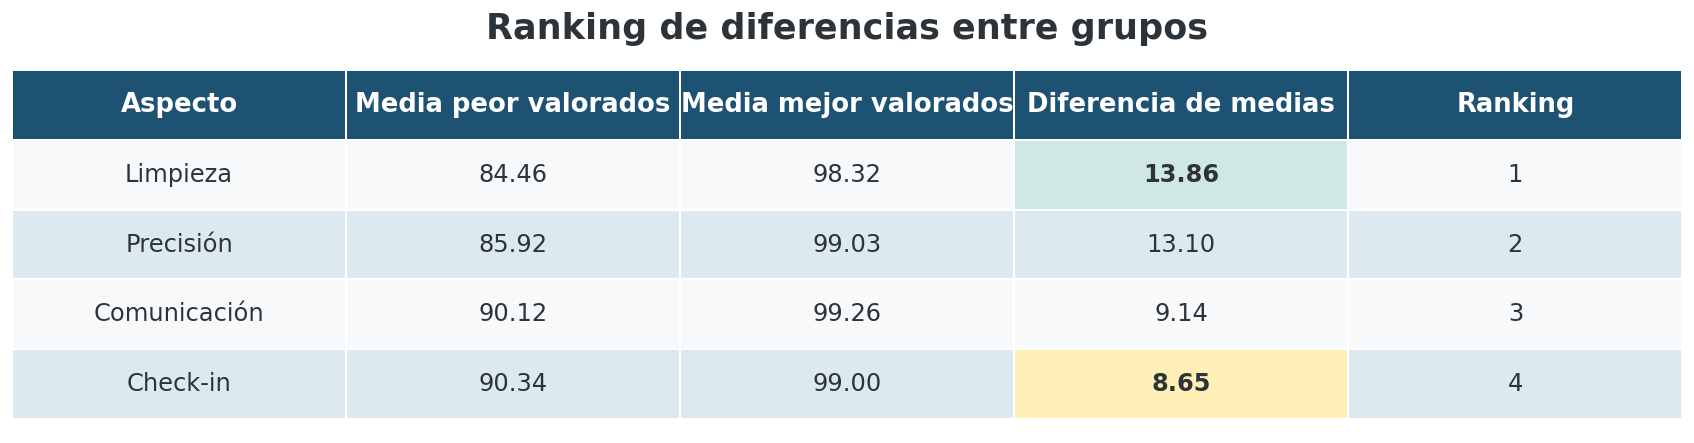

In [17]:
mean_table = (
    descriptive_results.pivot(
        index="Aspecto",
        columns="Grupo",
        values="Media",
    )
    .loc[list(ASPECT_COLUMNS_100)]
)

median_table = (
    descriptive_results.pivot(
        index="Aspecto",
        columns="Grupo",
        values="Mediana",
    )
    .loc[list(ASPECT_COLUMNS_100)]
)

gap_results = pd.DataFrame(
    {
        "Media mejor valorados": (
            mean_table["Mejor valorados"]
        ),
        "Media peor valorados": (
            mean_table["Peor valorados"]
        ),
        "Diferencia de medias": (
            mean_table["Mejor valorados"]
            - mean_table["Peor valorados"]
        ),
        "Mediana mejor valorados": (
            median_table["Mejor valorados"]
        ),
        "Mediana peor valorados": (
            median_table["Peor valorados"]
        ),
        "Diferencia de medianas": (
            median_table["Mejor valorados"]
            - median_table["Peor valorados"]
        ),
    }
)

gap_results["Ranking"] = (
    gap_results["Diferencia de medias"]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

gap_results = (
    gap_results
    .sort_values(
        "Diferencia de medias",
        ascending=False,
    )
    .reset_index()
)

gap_display = gap_results[
    [
        "Aspecto",
        "Media peor valorados",
        "Media mejor valorados",
        "Diferencia de medias",
        "Ranking",
    ]
]

graphic_table(
    gap_display,
    "Ranking de diferencias entre grupos",
    formats={
        "Media peor valorados": "{:.2f}",
        "Media mejor valorados": "{:.2f}",
        "Diferencia de medias": "{:.2f}",
        "Ranking": "{:.0f}",
    },
    highlight_max=[
        "Diferencia de medias",
    ],
    highlight_min=[
        "Diferencia de medias",
    ],
    width=14.5,
)

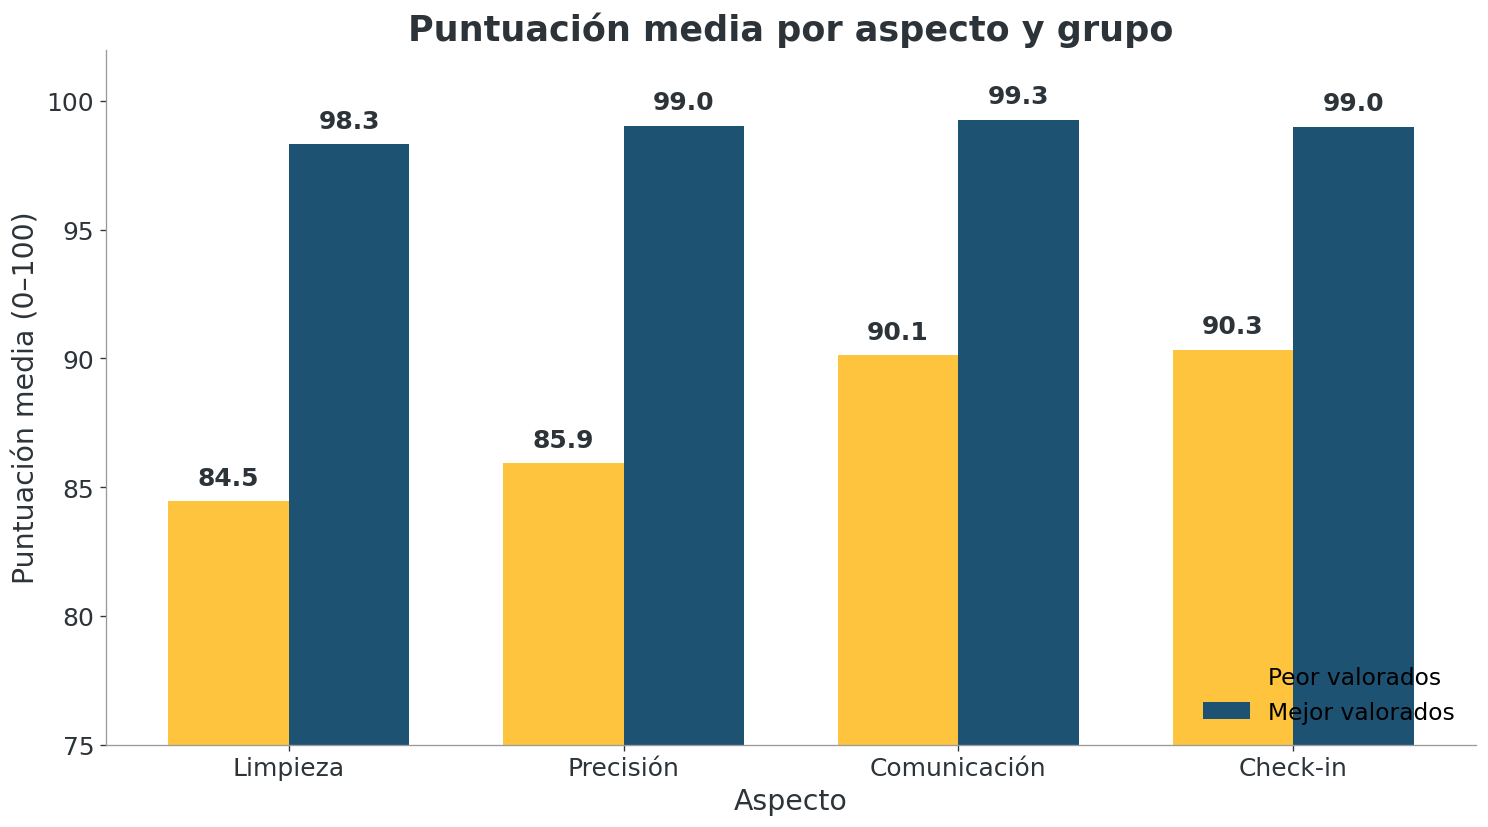

In [18]:
mean_chart = (
    gap_results.set_index("Aspecto")[
        [
            "Media peor valorados",
            "Media mejor valorados",
        ]
    ]
)

x = np.arange(len(mean_chart))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(12.5, 7))

bars_worst = ax.bar(
    x - bar_width / 2,
    mean_chart["Media peor valorados"],
    width=bar_width,
    color=YELLOW,
    label="Peor valorados",
)

bars_best = ax.bar(
    x + bar_width / 2,
    mean_chart["Media mejor valorados"],
    width=bar_width,
    color=NAVY,
    label="Mejor valorados",
)

ax.set(
    title="Puntuación media por aspecto y grupo",
    xlabel="Aspecto",
    ylabel="Puntuación media (0–100)",
    ylim=(75, 102),
)

ax.set_xticks(
    x,
    mean_chart.index,
)

ax.legend(
    frameon=False,
    loc="lower right",
)

for bars in [bars_worst, bars_best]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.45,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=DATA_LABEL_SIZE,
            fontweight="bold",
            color=DARK,
        )

plt.tight_layout()
plt.show()

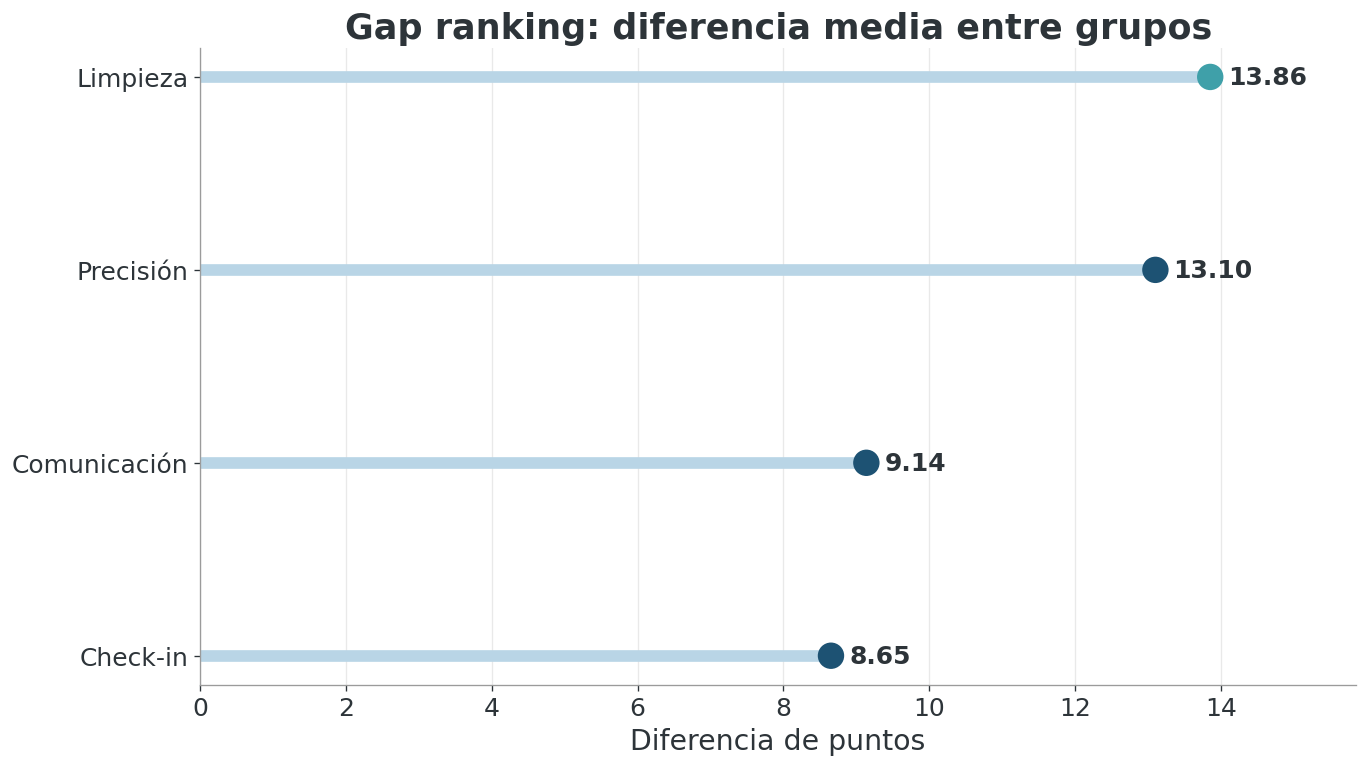

In [19]:
gap_plot = (
    gap_results[
        [
            "Aspecto",
            "Diferencia de medias",
        ]
    ]
    .sort_values("Diferencia de medias")
)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

y_positions = np.arange(len(gap_plot))

ax.hlines(
    y_positions,
    xmin=0,
    xmax=gap_plot["Diferencia de medias"],
    color=LIGHT_BLUE,
    linewidth=7,
)

ax.scatter(
    gap_plot["Diferencia de medias"],
    y_positions,
    s=220,
    color=[
        TEAL
        if aspect
        == gap_results.iloc[0]["Aspecto"]
        else NAVY
        for aspect in gap_plot["Aspecto"]
    ],
    zorder=3,
)

for y_position, value in zip(
    y_positions,
    gap_plot["Diferencia de medias"],
):
    ax.text(
        value + 0.25,
        y_position,
        f"{value:.2f}",
        va="center",
        fontsize=DATA_LABEL_SIZE,
        fontweight="bold",
        color=DARK,
    )

ax.set_yticks(
    y_positions,
    gap_plot["Aspecto"],
)

ax.set(
    title="Gap ranking: diferencia media entre grupos",
    xlabel="Diferencia de puntos",
    ylabel="",
    xlim=(0, gap_plot["Diferencia de medias"].max() + 2),
)

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Interpretación

**Limpieza** presenta la mayor diferencia media entre grupos,
con **13,86 puntos**, seguida de **precisión**, con
**13,10 puntos**. Comunicación alcanza una diferencia de
9,14 puntos y check-in de 8,65. Las diferencias de medianas
son iguales a 10 puntos, por lo que la diferencia de medias
permite distinguir mejor el orden de los cuatro aspectos.

## 7. Mann–Whitney U y tamaño del efecto

La prueba Mann–Whitney U evalúa si las distribuciones
de ambos grupos son diferentes. Su interpretación como
diferencia de localización o mediana requiere que las
formas de las distribuciones sean comparables.

La relevancia práctica se evalúa con el **delta de Cliff**:

- `|δ| < 0,147`: despreciable;
- `|δ| < 0,330`: pequeño;
- `|δ| < 0,474`: moderado;
- `|δ| ≥ 0,474`: grande.

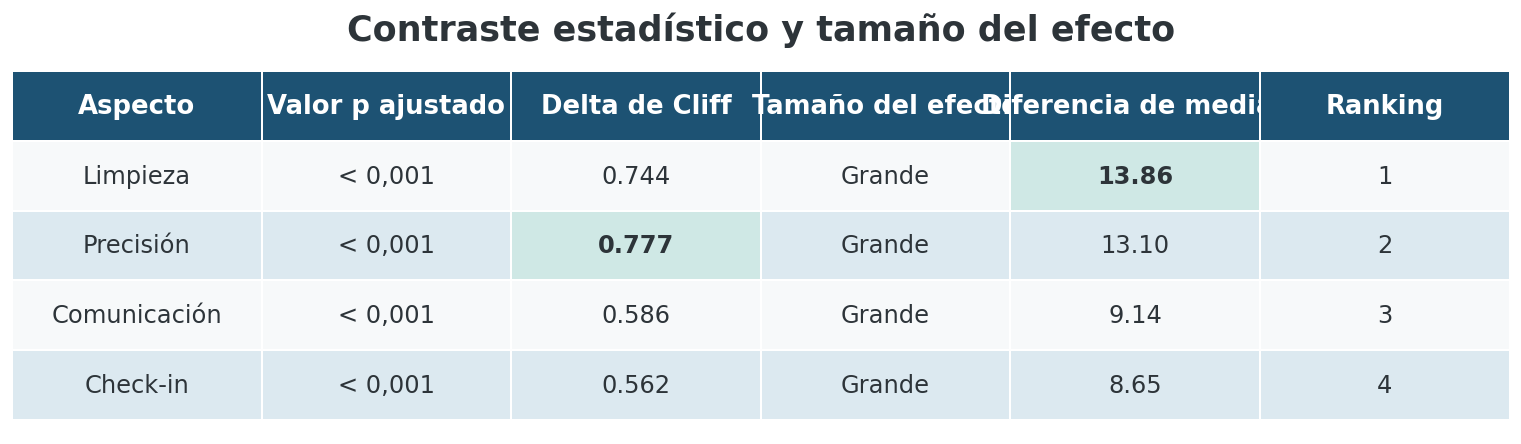

In [20]:
test_rows = []

for aspect, column in ASPECT_COLUMNS_100.items():
    best_values = df_extremes.loc[
        (
            df_extremes["grupo_valoracion"]
            == "Mejor valorados"
        ),
        column,
    ]

    worst_values = df_extremes.loc[
        (
            df_extremes["grupo_valoracion"]
            == "Peor valorados"
        ),
        column,
    ]

    (
        u_statistic,
        p_value,
        cliff_delta,
    ) = mann_whitney_effect(
        best_values,
        worst_values,
    )

    test_rows.append(
        {
            "Aspecto": aspect,
            "U": u_statistic,
            "Valor p": p_value,
            "Delta de Cliff": cliff_delta,
            "Tamaño del efecto": (
                effect_label(cliff_delta)
            ),
        }
    )

test_results = pd.DataFrame(test_rows)

test_results["Valor p ajustado"] = holm_adjust(
    test_results["Valor p"]
)

test_results["Significativa"] = np.where(
    test_results["Valor p ajustado"] < 0.05,
    "Sí",
    "No",
)

test_results = (
    test_results
    .merge(
        gap_results[
            [
                "Aspecto",
                "Diferencia de medias",
                "Ranking",
            ]
        ],
        on="Aspecto",
        how="left",
    )
    .sort_values("Ranking")
    .reset_index(drop=True)
)

test_display = test_results[
    [
        "Aspecto",
        "Valor p ajustado",
        "Delta de Cliff",
        "Tamaño del efecto",
        "Diferencia de medias",
        "Ranking",
    ]
].copy()

test_display["Valor p ajustado"] = (
    test_display["Valor p ajustado"]
    .map(p_value_label)
)

graphic_table(
    test_display,
    "Contraste estadístico y tamaño del efecto",
    formats={
        "Delta de Cliff": "{:.3f}",
        "Diferencia de medias": "{:.2f}",
        "Ranking": "{:.0f}",
    },
    highlight_max=[
        "Delta de Cliff",
        "Diferencia de medias",
    ],
    width=13,
)

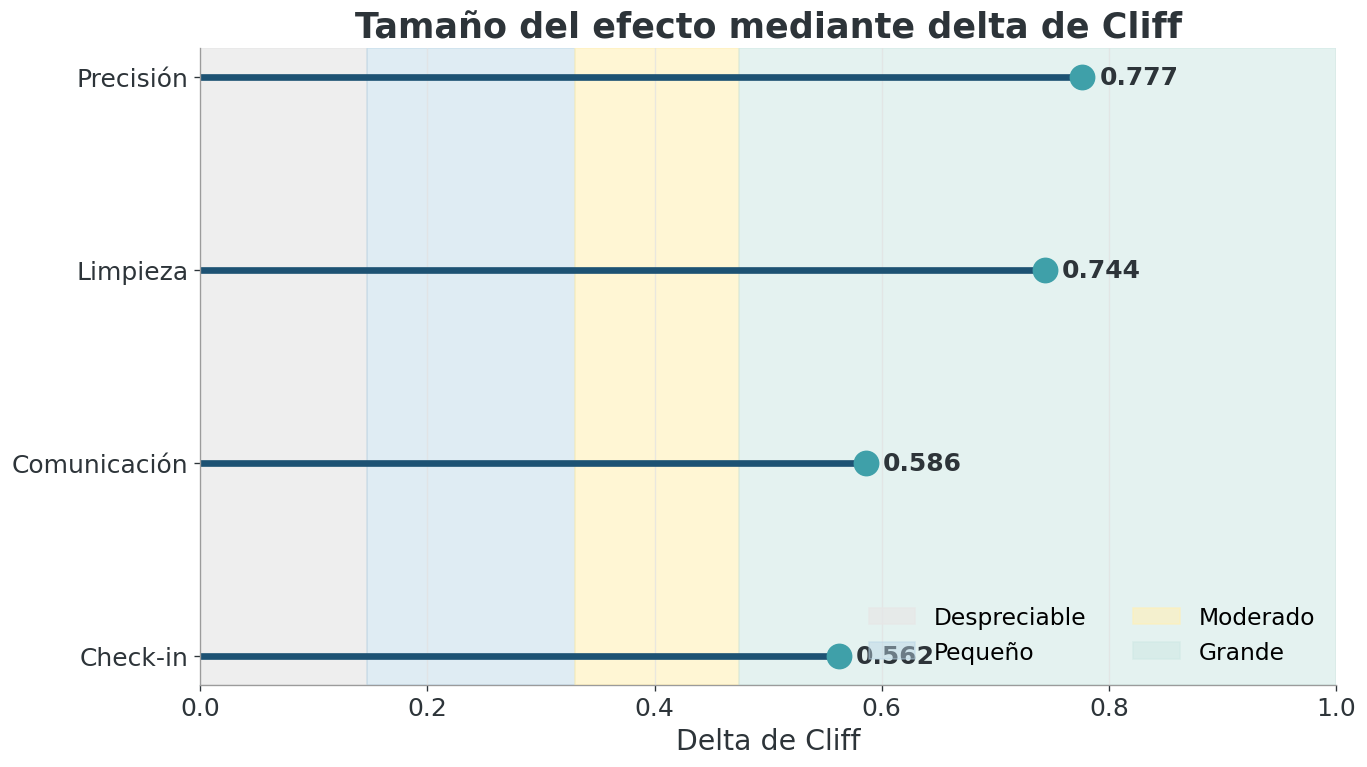

In [21]:
effect_plot = (
    test_results[
        [
            "Aspecto",
            "Delta de Cliff",
            "Tamaño del efecto",
        ]
    ]
    .copy()
    .sort_values("Delta de Cliff")
)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

y_positions = np.arange(len(effect_plot))

ax.axvspan(
    0,
    0.147,
    color=LIGHT_GREY,
    alpha=0.7,
    label="Despreciable",
)

ax.axvspan(
    0.147,
    0.330,
    color=LIGHT_BLUE,
    alpha=0.45,
    label="Pequeño",
)

ax.axvspan(
    0.330,
    0.474,
    color=LIGHT_YELLOW,
    alpha=0.6,
    label="Moderado",
)

ax.axvspan(
    0.474,
    1,
    color=LIGHT_TEAL,
    alpha=0.55,
    label="Grande",
)

ax.hlines(
    y_positions,
    xmin=0,
    xmax=effect_plot["Delta de Cliff"],
    color=NAVY,
    linewidth=4,
)

ax.scatter(
    effect_plot["Delta de Cliff"],
    y_positions,
    color=TEAL,
    s=210,
    zorder=3,
)

for y_position, value in zip(
    y_positions,
    effect_plot["Delta de Cliff"],
):
    ax.text(
        value + 0.015,
        y_position,
        f"{value:.3f}",
        va="center",
        fontsize=DATA_LABEL_SIZE,
        fontweight="bold",
        color=DARK,
    )

ax.set_yticks(
    y_positions,
    effect_plot["Aspecto"],
)

ax.set(
    title="Tamaño del efecto mediante delta de Cliff",
    xlabel="Delta de Cliff",
    ylabel="",
    xlim=(0, 1),
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="lower right",
)

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Interpretación

Las diferencias son estadísticamente significativas en los
cuatro aspectos después de aplicar la corrección de Holm
(`p ajustado < 0,001`). Todos presentan un tamaño del efecto
grande. Precisión obtiene el mayor delta de Cliff
(**0,777**), mientras que limpieza presenta el segundo mayor
(**0,744**). Por tanto, limpieza tiene la mayor diferencia
media, pero precisión muestra una separación ordinal
ligeramente más fuerte entre grupos.

## 8. Consistencia de los resultados entre ciudades

Se mantienen los cuartiles globales para aplicar la misma definición de “mejor” y “peor” en todas las ciudades.

Una ciudad se incluye cuando dispone de al menos **30 alojamientos en cada grupo**.

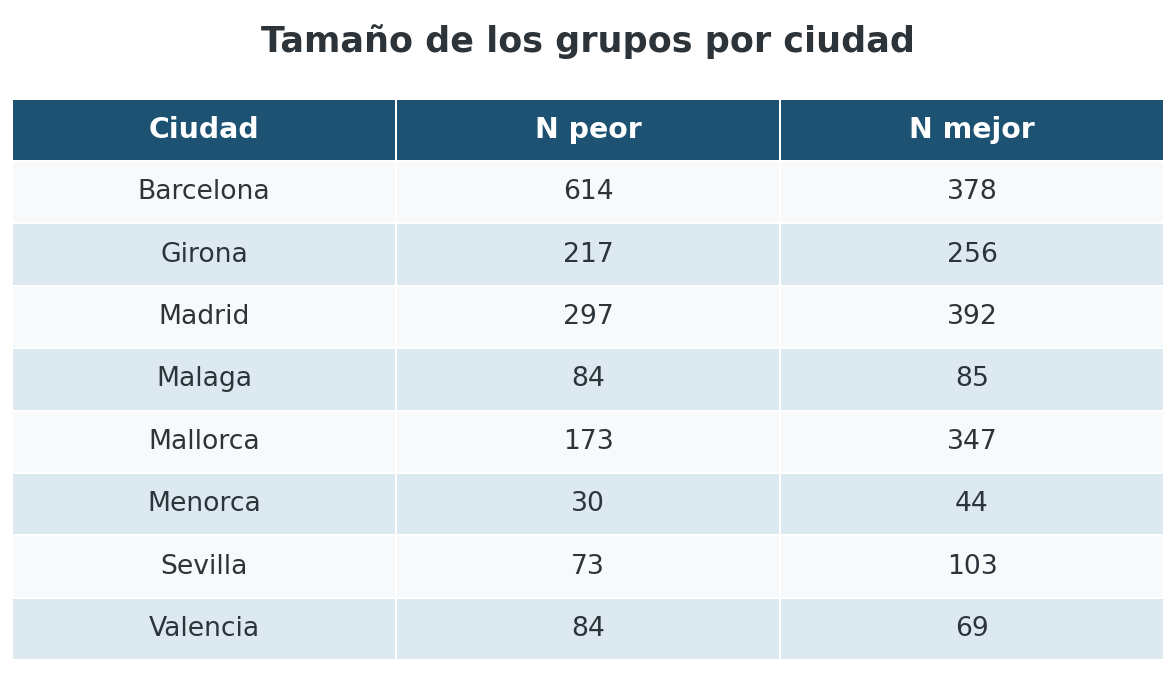

Ciudades incluidas: 8 de 8


In [22]:
MIN_GROUP_SIZE = 30

city_group_counts = (
    df_extremes
    .groupby(
        [
            "city",
            "grupo_valoracion",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=GROUP_ORDER)
)

eligible_cities = city_group_counts[
    (
        city_group_counts["Mejor valorados"]
        >= MIN_GROUP_SIZE
    )
    & (
        city_group_counts["Peor valorados"]
        >= MIN_GROUP_SIZE
    )
].index.tolist()

city_group_table = (
    city_group_counts
    .reset_index()
    .rename(
        columns={
            "city": "Ciudad",
            "Peor valorados": "N peor",
            "Mejor valorados": "N mejor",
        }
    )
)

graphic_table(
    city_group_table,
    "Tamaño de los grupos por ciudad",
    formats={
        "N peor": "{:,.0f}",
        "N mejor": "{:,.0f}",
    },
    width=10,
)

print(
    "Ciudades incluidas: "
    f"{len(eligible_cities)} de "
    f"{df_extremes['city'].nunique()}"
)

### Interpretación

Las ocho ciudades cumplen el criterio mínimo de 30
alojamientos en cada grupo. Menorca presenta la muestra más
pequeña, con 30 alojamientos peor valorados y 44 mejor
valorados, por lo que sus estimaciones son menos estables
que las de Barcelona, Madrid o Mallorca.

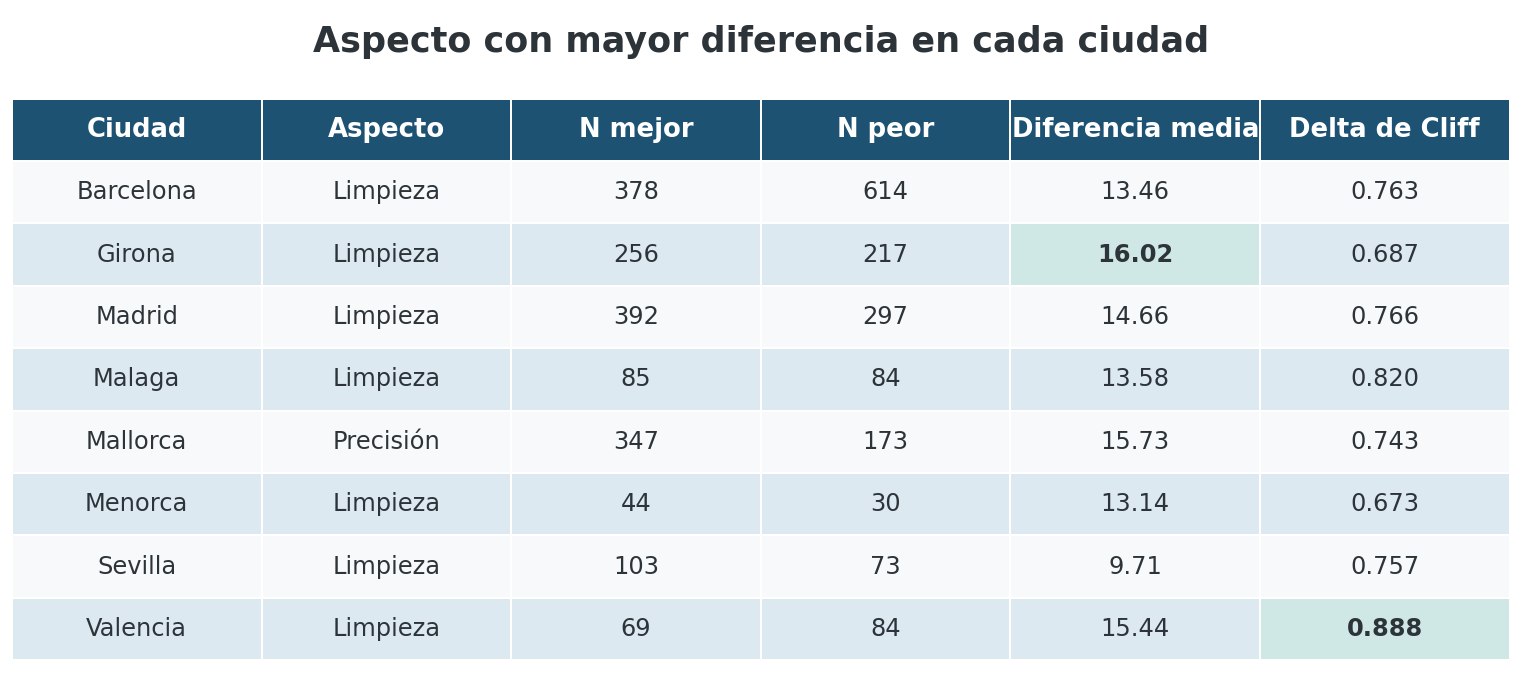

In [23]:
city_rows = []

for city in eligible_cities:
    city_data = df_extremes[
        df_extremes["city"] == city
    ]

    for aspect, column in ASPECT_COLUMNS_100.items():
        best_values = city_data.loc[
            (
                city_data["grupo_valoracion"]
                == "Mejor valorados"
            ),
            column,
        ]

        worst_values = city_data.loc[
            (
                city_data["grupo_valoracion"]
                == "Peor valorados"
            ),
            column,
        ]

        (
            _,
            _,
            cliff_delta,
        ) = mann_whitney_effect(
            best_values,
            worst_values,
        )

        city_rows.append(
            {
                "Ciudad": city,
                "Aspecto": aspect,
                "N mejor": len(best_values),
                "N peor": len(worst_values),
                "Media mejor": (
                    best_values.mean()
                ),
                "Media peor": (
                    worst_values.mean()
                ),
                "Diferencia media": (
                    best_values.mean()
                    - worst_values.mean()
                ),
                "Delta de Cliff": cliff_delta,
            }
        )

city_results = pd.DataFrame(city_rows)

city_winners = (
    city_results.loc[
        city_results
        .groupby("Ciudad")[
            "Diferencia media"
        ]
        .idxmax()
    ]
    .sort_values("Ciudad")
    .reset_index(drop=True)
)

graphic_table(
    city_winners[
        [
            "Ciudad",
            "Aspecto",
            "N mejor",
            "N peor",
            "Diferencia media",
            "Delta de Cliff",
        ]
    ],
    "Aspecto con mayor diferencia en cada ciudad",
    formats={
        "N mejor": "{:,.0f}",
        "N peor": "{:,.0f}",
        "Diferencia media": "{:.2f}",
        "Delta de Cliff": "{:.3f}",
    },
    highlight_max=[
        "Diferencia media",
        "Delta de Cliff",
    ],
    width=13,
)

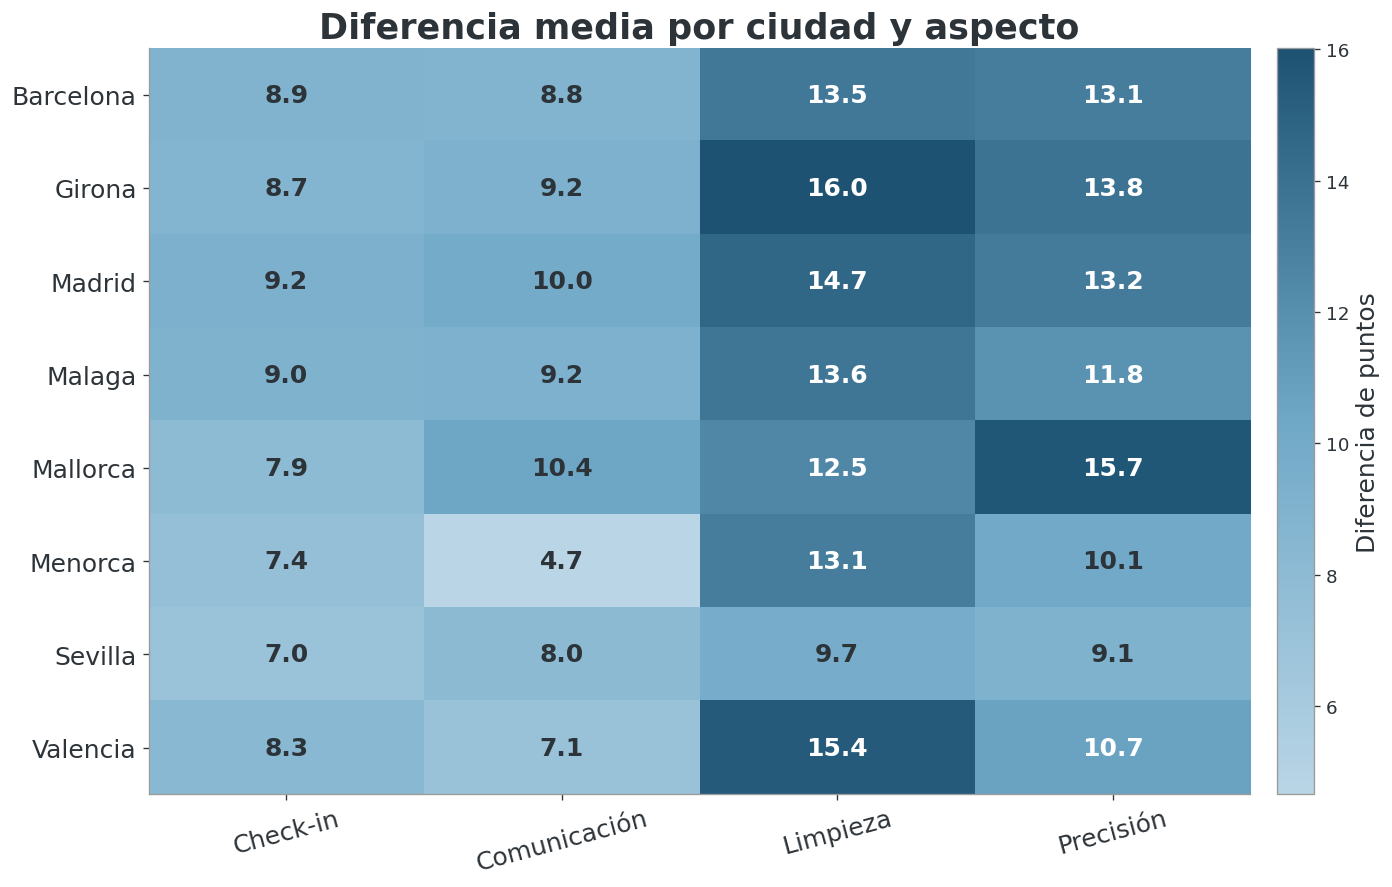

In [24]:
city_gap_matrix = (
    city_results.pivot(
        index="Ciudad",
        columns="Aspecto",
        values="Diferencia media",
    )
    .loc[eligible_cities]
)

fig, ax = plt.subplots(figsize=(12.5, 7.5))

image = ax.imshow(
    city_gap_matrix,
    aspect="auto",
    cmap=BLUE_CMAP,
)

ax.set_title(
    "Diferencia media por ciudad y aspecto"
)

ax.set_xticks(
    range(len(city_gap_matrix.columns)),
    city_gap_matrix.columns,
    rotation=15,
)

ax.set_yticks(
    range(len(city_gap_matrix.index)),
    city_gap_matrix.index,
)

for row_index in range(
    len(city_gap_matrix.index)
):
    for column_index in range(
        len(city_gap_matrix.columns)
    ):
        value = city_gap_matrix.iloc[
            row_index,
            column_index,
        ]

        text_color = (
            WHITE
            if value
            > city_gap_matrix.to_numpy().mean()
            else DARK
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=DATA_LABEL_SIZE,
            fontweight="bold",
            color=text_color,
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02,
)

colorbar.set_label(
    "Diferencia de puntos",
    fontsize=DATA_LABEL_SIZE,
)

colorbar.ax.tick_params(
    labelsize=11,
)

plt.tight_layout()
plt.show()

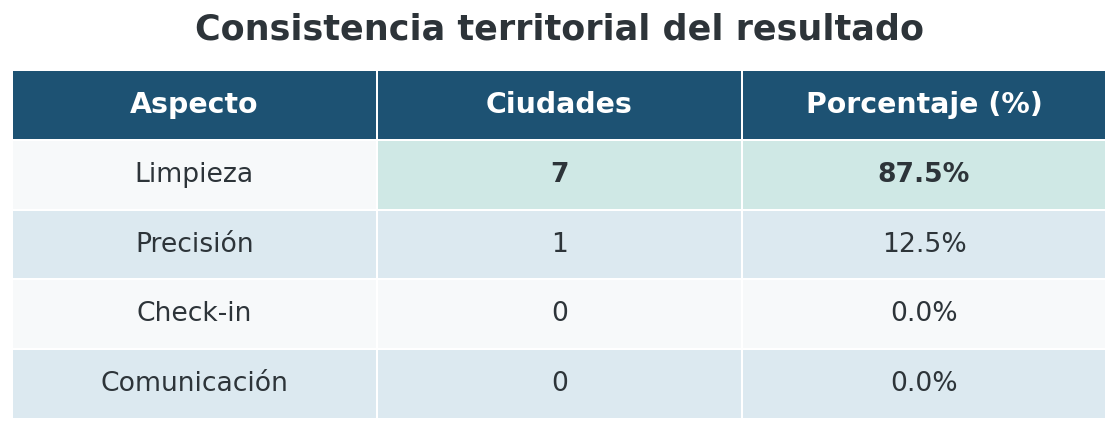

In [25]:
winner_summary = (
    city_winners["Aspecto"]
    .value_counts()
    .reindex(
        list(ASPECT_COLUMNS_100),
        fill_value=0,
    )
    .rename_axis("Aspecto")
    .reset_index(name="Ciudades")
)

winner_summary["Porcentaje (%)"] = (
    winner_summary["Ciudades"]
    / len(eligible_cities)
    * 100
)

winner_summary = (
    winner_summary
    .sort_values(
        ["Ciudades", "Aspecto"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

graphic_table(
    winner_summary,
    "Consistencia territorial del resultado",
    formats={
        "Ciudades": "{:.0f}",
        "Porcentaje (%)": "{:.1f}%",
    },
    highlight_max=[
        "Ciudades",
        "Porcentaje (%)",
    ],
    width=9.5,
)

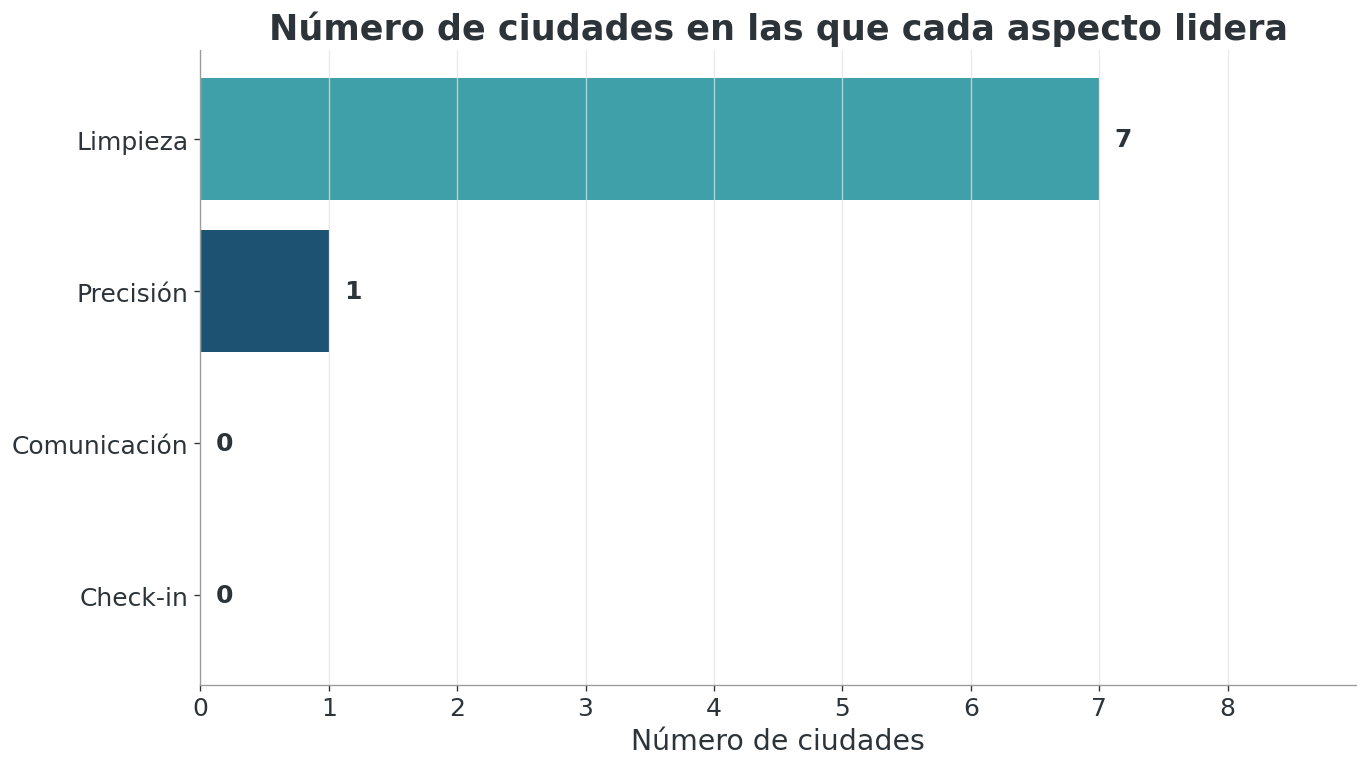

In [26]:
winner_plot = winner_summary.sort_values(
    "Ciudades"
)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

colors = [
    TEAL
    if value == winner_plot["Ciudades"].max()
    else NAVY
    for value in winner_plot["Ciudades"]
]

bars = ax.barh(
    winner_plot["Aspecto"],
    winner_plot["Ciudades"],
    color=colors,
)

ax.set(
    title="Número de ciudades en las que cada aspecto lidera",
    xlabel="Número de ciudades",
    ylabel="",
    xlim=(0, len(eligible_cities) + 1),
)

for bar, value in zip(
    bars,
    winner_plot["Ciudades"],
):
    ax.text(
        value + 0.12,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center",
        fontsize=DATA_LABEL_SIZE,
        fontweight="bold",
        color=DARK,
    )

ax.set_xticks(
    range(0, len(eligible_cities) + 1)
)

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Interpretación

Limpieza presenta la mayor diferencia en **7 de las 8
ciudades (87,5 %)**. Precisión ocupa el primer lugar solo
en Mallorca. Las mayores diferencias de limpieza aparecen
en Girona y Valencia, aunque la menor cobertura de Girona
obliga a interpretar ese resultado con cautela.

## 9. Análisis de sensibilidad con umbrales fijos

Como comprobación secundaria se utiliza una definición empresarial:

- **Mejor valorados:** puntuación general ≥ 90.
- **Peor valorados:** puntuación general < 80.

Este análisis no sustituye la segmentación principal. Permite comprobar si el ranking depende de los puntos de corte elegidos.

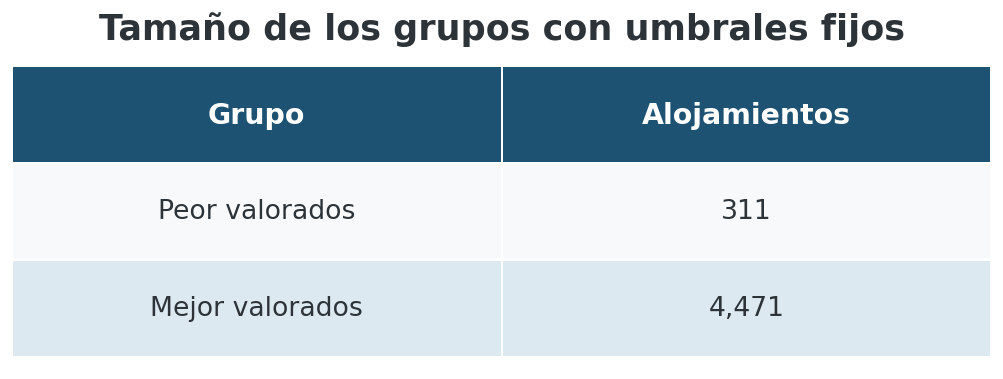

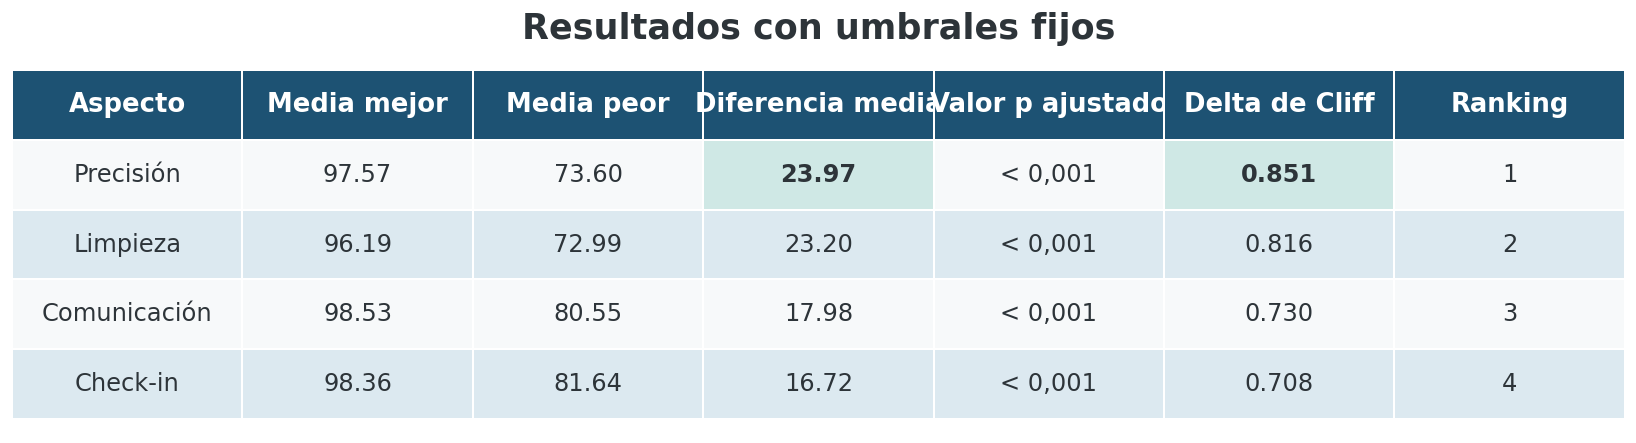

In [27]:
df_complete["grupo_umbral_fijo"] = np.select(
    [
        df_complete["rating_general_100"] < 80,
        df_complete["rating_general_100"] >= 90,
    ],
    [
        "Peor valorados",
        "Mejor valorados",
    ],
    default="Intermedios",
)

fixed_extremes = df_complete[
    df_complete["grupo_umbral_fijo"].isin(
        GROUP_ORDER
    )
].copy()

fixed_group_counts = (
    fixed_extremes["grupo_umbral_fijo"]
    .value_counts()
    .reindex(GROUP_ORDER)
    .rename_axis("Grupo")
    .reset_index(name="Alojamientos")
)

graphic_table(
    fixed_group_counts,
    "Tamaño de los grupos con umbrales fijos",
    formats={
        "Alojamientos": "{:,.0f}",
    },
    width=8.5,
)

sensitivity_rows = []

for aspect, column in ASPECT_COLUMNS_100.items():
    best_values = fixed_extremes.loc[
        (
            fixed_extremes["grupo_umbral_fijo"]
            == "Mejor valorados"
        ),
        column,
    ]

    worst_values = fixed_extremes.loc[
        (
            fixed_extremes["grupo_umbral_fijo"]
            == "Peor valorados"
        ),
        column,
    ]

    (
        u_statistic,
        p_value,
        cliff_delta,
    ) = mann_whitney_effect(
        best_values,
        worst_values,
    )

    sensitivity_rows.append(
        {
            "Aspecto": aspect,
            "Media mejor": best_values.mean(),
            "Media peor": worst_values.mean(),
            "Diferencia media": (
                best_values.mean()
                - worst_values.mean()
            ),
            "U": u_statistic,
            "Valor p": p_value,
            "Delta de Cliff": cliff_delta,
        }
    )

sensitivity_results = pd.DataFrame(
    sensitivity_rows
)

sensitivity_results[
    "Valor p ajustado"
] = holm_adjust(
    sensitivity_results["Valor p"]
)

sensitivity_results = (
    sensitivity_results
    .sort_values(
        "Diferencia media",
        ascending=False,
    )
    .reset_index(drop=True)
)

sensitivity_results["Ranking"] = (
    sensitivity_results.index + 1
)

sensitivity_display = sensitivity_results[
    [
        "Aspecto",
        "Media mejor",
        "Media peor",
        "Diferencia media",
        "Valor p ajustado",
        "Delta de Cliff",
        "Ranking",
    ]
].copy()

sensitivity_display[
    "Valor p ajustado"
] = (
    sensitivity_display[
        "Valor p ajustado"
    ]
    .map(p_value_label)
)

graphic_table(
    sensitivity_display,
    "Resultados con umbrales fijos",
    formats={
        "Media mejor": "{:.2f}",
        "Media peor": "{:.2f}",
        "Diferencia media": "{:.2f}",
        "Delta de Cliff": "{:.3f}",
        "Ranking": "{:.0f}",
    },
    highlight_max=[
        "Diferencia media",
        "Delta de Cliff",
    ],
    width=14,
)

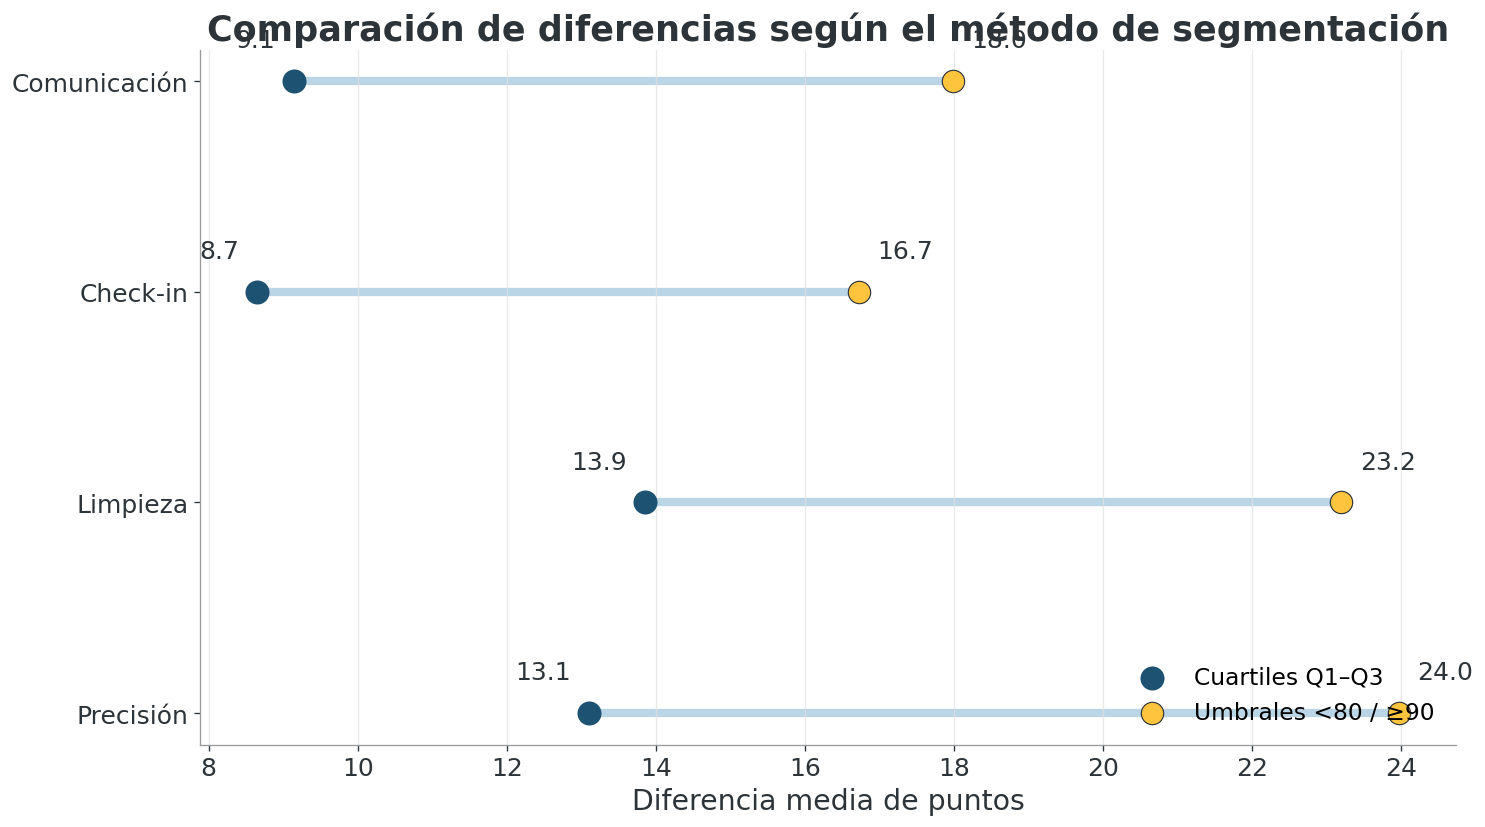

In [28]:
comparison_ranking = (
    gap_results[
        [
            "Aspecto",
            "Diferencia de medias",
        ]
    ]
    .rename(
        columns={
            "Diferencia de medias":
            "Cuartiles Q1–Q3"
        }
    )
    .merge(
        sensitivity_results[
            [
                "Aspecto",
                "Diferencia media",
            ]
        ].rename(
            columns={
                "Diferencia media":
                "Umbrales <80 / ≥90"
            }
        ),
        on="Aspecto",
        how="left",
    )
    .set_index("Aspecto")
)

comparison_ranking = comparison_ranking.loc[
    list(ASPECT_COLUMNS_100)
]

fig, ax = plt.subplots(figsize=(12.5, 7))

y_positions = np.arange(
    len(comparison_ranking)
)

for y_position, (
    aspect,
    row,
) in enumerate(comparison_ranking.iterrows()):
    first_value = row["Cuartiles Q1–Q3"]
    second_value = row["Umbrales <80 / ≥90"]

    ax.plot(
        [first_value, second_value],
        [y_position, y_position],
        color=LIGHT_BLUE,
        linewidth=5,
        zorder=1,
    )

    ax.scatter(
        first_value,
        y_position,
        color=NAVY,
        s=180,
        label=(
            "Cuartiles Q1–Q3"
            if y_position == 0
            else None
        ),
        zorder=2,
    )

    ax.scatter(
        second_value,
        y_position,
        color=YELLOW,
        edgecolor=DARK,
        linewidth=0.7,
        s=180,
        label=(
            "Umbrales <80 / ≥90"
            if y_position == 0
            else None
        ),
        zorder=2,
    )

    ax.text(
        first_value - 0.25,
        y_position + 0.16,
        f"{first_value:.1f}",
        ha="right",
        fontsize=DATA_LABEL_SIZE,
        color=DARK,
    )

    ax.text(
        second_value + 0.25,
        y_position + 0.16,
        f"{second_value:.1f}",
        ha="left",
        fontsize=DATA_LABEL_SIZE,
        color=DARK,
    )

ax.set_yticks(
    y_positions,
    comparison_ranking.index,
)

ax.set(
    title="Comparación de diferencias según el método de segmentación",
    xlabel="Diferencia media de puntos",
    ylabel="",
)

ax.legend(
    frameon=False,
    loc="lower right",
)

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Interpretación

Con los umbrales empresariales, precisión pasa al primer
lugar con una diferencia de **23,97 puntos**, seguida de
limpieza con **23,20 puntos**. Los grupos quedan muy
desequilibrados: 311 alojamientos peor valorados frente a
4.471 mejor valorados. Por tanto, los dos aspectos
prioritarios se mantienen, aunque su orden depende del
método de segmentación.

## 10. Riesgos potenciales de sesgo y limitaciones

Los siguientes elementos se consideran riesgos potenciales
y no sesgos demostrados:

- **Selección y no respuesta:** el análisis utiliza únicamente
  alojamientos con la puntuación general y los cuatro aspectos
  completos. Si los alojamientos sin valoraciones completas
  presentan características diferentes, los resultados no
  serán plenamente representativos del conjunto del dataset.

- **Información y medición:** las puntuaciones son valoraciones
  subjetivas, agregadas, acotadas y con efecto techo. Además,
  la puntuación general y los aspectos específicos proceden
  del mismo proceso de evaluación.

- **Condicionamiento por la puntuación general:** los grupos
  mejor y peor valorados se definen mediante una variable
  relacionada con los cuatro aspectos. Por ello, los resultados
  muestran capacidad descriptiva para distinguir los grupos,
  pero no efectos causales independientes.

- **Confusión:** ciudad, precio, tipo de alojamiento, capacidad,
  número de reviews y otros factores podrían influir en las
  diferencias observadas. La comparación por ciudad reduce
  parcialmente este riesgo, pero no controla todos los factores.

- **Sesgo cronológico potencial:** los últimos snapshots
  disponibles no corresponden al mismo momento para todos
  los alojamientos, por lo que posibles cambios temporales
  podrían afectar los resultados.

- **Data-dredging y sesgo de confirmación:** la metodología
  principal fue definida previamente en la justificación
  técnica. Se presentan los resultados de los cuatro aspectos
  y del análisis de sensibilidad, incluso cuando el orden
  de prioridad cambia.

- **Comparaciones múltiples:** se realizan cuatro contrastes
  principales. Los valores p se ajustan mediante el método
  de Holm para reducir el riesgo de falsos positivos.

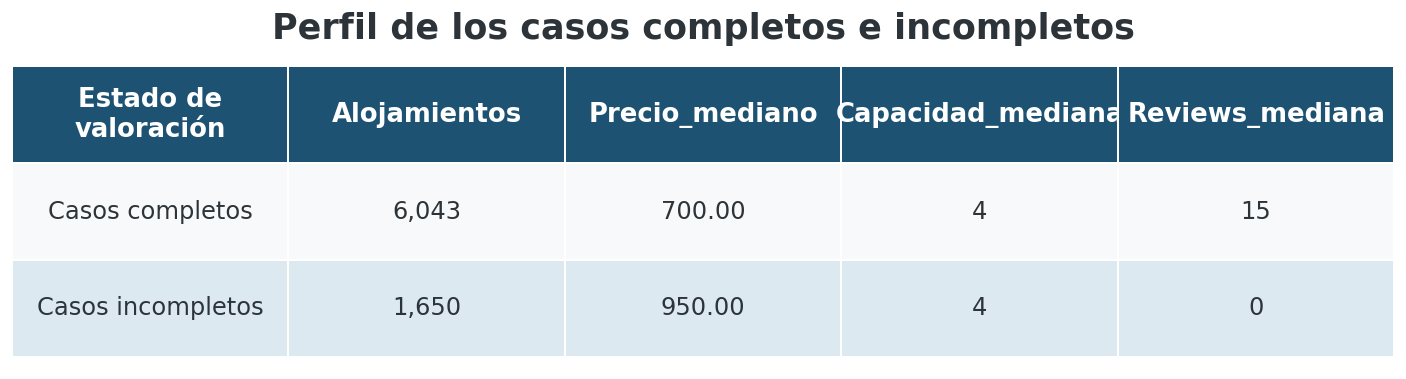

In [29]:
df_bias_profile = df.copy()

df_bias_profile[
    "Estado de valoración"
] = np.where(
    df_bias_profile[
        [
            "rating_general_100",
            *ASPECT_COLUMNS_100.values(),
        ]
    ].notna().all(axis=1),
    "Casos completos",
    "Casos incompletos",
)

bias_profile = (
    df_bias_profile
    .groupby(
        "Estado de valoración",
        as_index=False,
    )
    .agg(
        Alojamientos=(
            "apartment_id",
            "nunique",
        ),
        Precio_mediano=(
            "price_€",
            "median",
        ),
        Capacidad_mediana=(
            "accommodates",
            "median",
        ),
        Reviews_mediana=(
            "number_of_reviews",
            "median",
        ),
    )
)

graphic_table(
    bias_profile,
    "Perfil de los casos completos e incompletos",
    formats={
        "Alojamientos": "{:,.0f}",
        "Precio_mediano": "{:.2f}",
        "Capacidad_mediana": "{:.0f}",
        "Reviews_mediana": "{:.0f}",
    },
    width=12,
)

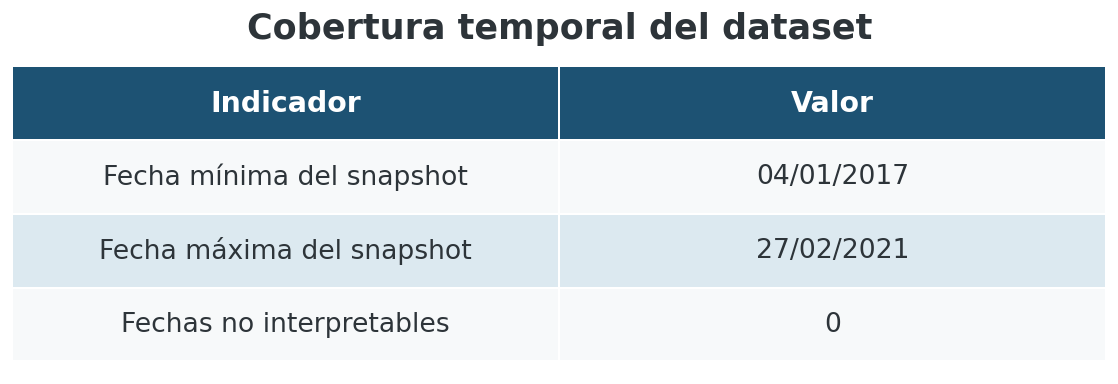

In [30]:
df["insert_date_parsed"] = pd.to_datetime(
    df["insert_date"],
    errors="coerce",
)

temporal_summary = pd.DataFrame(
    {
        "Indicador": [
            "Fecha mínima del snapshot",
            "Fecha máxima del snapshot",
            "Fechas no interpretables",
        ],
        "Valor": [
            df["insert_date_parsed"]
            .min()
            .strftime("%d/%m/%Y"),
            df["insert_date_parsed"]
            .max()
            .strftime("%d/%m/%Y"),
            df["insert_date_parsed"]
            .isna()
            .sum(),
        ],
    }
)

graphic_table(
    temporal_summary,
    "Cobertura temporal del dataset",
    width=9.5,
)

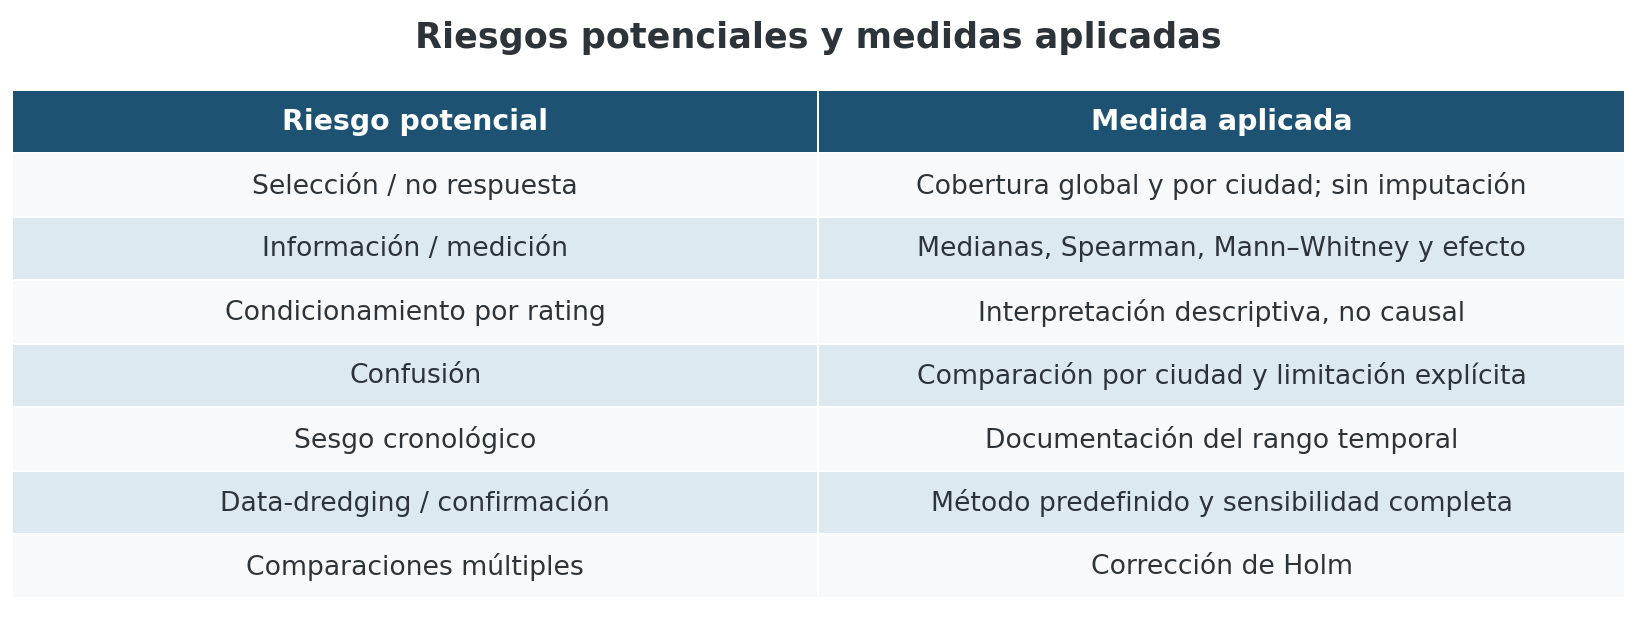

In [31]:
bias_register = pd.DataFrame(
    {
        "Riesgo potencial": [
            "Selección / no respuesta",
            "Información / medición",
            "Condicionamiento por rating",
            "Confusión",
            "Sesgo cronológico",
            "Data-dredging / confirmación",
            "Comparaciones múltiples",
        ],
        "Medida aplicada": [
            "Cobertura global y por ciudad; sin imputación",
            "Medianas, Spearman, Mann–Whitney y efecto",
            "Interpretación descriptiva, no causal",
            "Comparación por ciudad y limitación explícita",
            "Documentación del rango temporal",
            "Método predefinido y sensibilidad completa",
            "Corrección de Holm",
        ],
    }
)

graphic_table(
    bias_register,
    "Riesgos potenciales y medidas aplicadas",
    width=14,
)

### Interpretación

Los snapshots abarcan desde enero de 2017 hasta febrero de
2021, por lo que los alojamientos no están observados
exactamente en el mismo momento. Además, los casos completos
e incompletos pueden presentar perfiles diferentes. Los
resultados deben interpretarse como asociaciones dentro de
la muestra analizada y no como relaciones causales.

## 11. Respuesta y recomendación de negocio

In [32]:
main_aspect = gap_results.iloc[0]["Aspecto"]

main_gap = gap_results.iloc[0][
    "Diferencia de medias"
]

main_best_mean = gap_results.iloc[0][
    "Media mejor valorados"
]

main_worst_mean = gap_results.iloc[0][
    "Media peor valorados"
]

main_test = (
    test_results
    .set_index("Aspecto")
    .loc[main_aspect]
)

main_adjusted_p = (
    main_test["Valor p ajustado"]
)

main_effect = (
    main_test["Tamaño del efecto"]
)

effect_leader = (
    test_results
    .set_index("Aspecto")[
        "Delta de Cliff"
    ]
    .abs()
    .idxmax()
)

effect_leader_value = (
    test_results
    .set_index("Aspecto")
    .loc[
        effect_leader,
        "Delta de Cliff",
    ]
)

territorial_row = winner_summary.loc[
    winner_summary["Ciudades"].idxmax()
]

territorial_leader = (
    territorial_row["Aspecto"]
)

territorial_cities = int(
    territorial_row["Ciudades"]
)

territorial_percentage = (
    territorial_row["Porcentaje (%)"]
)

sensitivity_leader = (
    sensitivity_results.iloc[0]["Aspecto"]
)

action_map = {
    "Limpieza": (
        "reforzar los protocolos de limpieza, "
        "utilizar checklists por estancia y "
        "realizar controles de calidad"
    ),
    "Precisión": (
        "revisar periódicamente las "
        "descripciones, los servicios, "
        "las fotografías y las normas publicadas"
    ),
    "Check-in": (
        "estandarizar las instrucciones, "
        "confirmar la información antes de "
        "la llegada y simplificar el acceso"
    ),
    "Comunicación": (
        "definir tiempos máximos de respuesta, "
        "utilizar plantillas y realizar un "
        "seguimiento proactivo"
    ),
}

significance_text = (
    "estadísticamente significativa"
    if main_adjusted_p < 0.05
    else "no estadísticamente significativa"
)

recommendation = action_map[main_aspect]

display(
    Markdown(
        f"""
### Respuesta a la pregunta de negocio

El aspecto que presenta la mayor diferencia media entre
los alojamientos mejor y peor valorados es
**{main_aspect}**, con una diferencia de
**{main_gap:.2f} puntos**.

Los alojamientos mejor valorados obtienen una media de
**{main_best_mean:.2f}**, frente a
**{main_worst_mean:.2f}** en los peor valorados.

La diferencia es **{significance_text}** después de la
corrección de Holm
(`p ajustado {p_value_label(main_adjusted_p)}`) y presenta
un tamaño del efecto **{main_effect.lower()}**.

**{territorial_leader}** ocupa el primer puesto en
**{territorial_cities} de {len(eligible_cities)}
ciudades** (**{territorial_percentage:.1f} %**).

Por lo tanto, se recomienda **{recommendation}** en los
alojamientos con menor valoración general.
"""
    )
)


### Respuesta a la pregunta de negocio

El aspecto que presenta la mayor diferencia media entre
los alojamientos mejor y peor valorados es
**Limpieza**, con una diferencia de
**13.86 puntos**.

Los alojamientos mejor valorados obtienen una media de
**98.32**, frente a
**84.46** en los peor valorados.

La diferencia es **estadísticamente significativa** después de la
corrección de Holm
(`p ajustado < 0,001`) y presenta
un tamaño del efecto **grande**.

**Limpieza** ocupa el primer puesto en
**7 de 8
ciudades** (**87.5 %**).

Por lo tanto, se recomienda **reforzar los protocolos de limpieza, utilizar checklists por estancia y realizar controles de calidad** en los
alojamientos con menor valoración general.


In [33]:
display(
    Markdown(
        f"""
### Matices para la interpretación

- **{main_aspect}** presenta la mayor diferencia media.
- **{effect_leader}** presenta el mayor tamaño del efecto
  (`|δ| = {abs(effect_leader_value):.3f}`).
- Con umbrales empresariales, el primer puesto corresponde
  a **{sensitivity_leader}**.

La priorización debe considerar conjuntamente la
magnitud de la diferencia, el tamaño del efecto, la
significación estadística y la consistencia territorial.
Por ello, se prioriza **{main_aspect}** como oportunidad
global y territorial, manteniendo **{effect_leader}**
como segunda línea prioritaria.
"""
    )
)


### Matices para la interpretación

- **Limpieza** presenta la mayor diferencia media.
- **Precisión** presenta el mayor tamaño del efecto
  (`|δ| = 0.777`).
- Con umbrales empresariales, el primer puesto corresponde
  a **Precisión**.

La priorización debe considerar conjuntamente la
magnitud de la diferencia, el tamaño del efecto, la
significación estadística y la consistencia territorial.
Por ello, se prioriza **Limpieza** como oportunidad
global y territorial, manteniendo **Precisión**
como segunda línea prioritaria.


### Alcance de la conclusión

Estos resultados son aplicables a los alojamientos de las
ocho ciudades incluidos en el dataset y con valoraciones
completas. Las diferencias observadas son descriptivas y
no demuestran que modificar un aspecto cause por sí solo
un aumento de la puntuación general.

La segmentación excluye aproximadamente la mitad central
de la distribución; en este dataset, el grupo intermedio
representa el 46,28 %. Las diferencias de cobertura entre
ciudades y la antigüedad desigual de los snapshots limitan
la generalización.

## 12. Próximos pasos

- Repetir el análisis con otros puntos de corte.
- Estimar intervalos de confianza mediante bootstrap.
- Controlar ciudad, precio, tipo de alojamiento, capacidad y número de reviews mediante modelos multivariables.
- Analizar el texto de las reseñas para identificar causas concretas.
- Validar las conclusiones con datos más recientes.

## Referencias de trabajo

- `Guió desafiament Nº2`.
- `Justificacion_Tecnica_Experiencia_Cliente_06_07_2026_FINAL.docx`.
- `Data_Understanding_06_07_2026`.
- `Instrucciones para Analistas de Datos Junior`.
- *Catalogue of Bias*.